<a href="https://colab.research.google.com/github/objectrom/Flight-LTO-Emission/blob/main/Data_collecting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

gaseous = pd.read_excel('/content/emissions_indices.xlsx',
                        sheet_name='Gaseous Emissions and Smoke')

nvpm = pd.read_excel('/content/emissions_indices.xlsx',
                     sheet_name='nvPM Emissions')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/MASTER.txt', sep=',', low_memory=False)

In [ ]:
df.columns

Index(['N-NUMBER', 'SERIAL NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'YEAR MFR',
       'TYPE REGISTRANT', 'NAME', 'STREET', 'STREET2', 'CITY', 'STATE',
       'ZIP CODE', 'REGION', 'COUNTY', 'COUNTRY', 'LAST ACTION DATE',
       'CERT ISSUE DATE', 'CERTIFICATION', 'TYPE AIRCRAFT', 'TYPE ENGINE',
       'STATUS CODE', 'MODE S CODE', 'FRACT OWNER', 'AIR WORTH DATE',
       'OTHER NAMES(1)', 'OTHER NAMES(2)', 'OTHER NAMES(3)', 'OTHER NAMES(4)',
       'OTHER NAMES(5)', 'EXPIRATION DATE', 'UNIQUE ID', 'KIT MFR',
       ' KIT MODEL', 'MODE S CODE HEX', 'Unnamed: 34'],
      dtype='object')

In [ ]:
faa = df[['N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL']]

In [ ]:
faa.head()

,N-NUMBER,MFR MDL CODE,ENG MFR MDL
0,100,7100510,17003
1,10000,2130004,
2,10001,9601202,67007
3,10004,2072738,
4,10006,1152020,17026


In [ ]:
acft = pd.read_csv('/content/ACFTREF.txt')
eng  = pd.read_csv('/content/ENGINE.txt')

# join
acft['CODE'] = acft['CODE'].astype(str).str.strip()
faa['MFR MDL CODE'] = faa['MFR MDL CODE'].astype(str).str.strip()

faa = faa.merge(acft[['CODE','MFR','MODEL']], left_on='MFR MDL CODE', right_on='CODE', how='left')
faa = faa.rename(columns={'MFR':'ACFT MFR', 'MODEL':'ACFT MODEL'})
faa = faa.drop(columns=['CODE'])

/tmp/ipykernel_17114/1176155836.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  faa['MFR MDL CODE'] = faa['MFR MDL CODE'].astype(str).str.strip()


In [ ]:
faa.head()

,N-NUMBER,MFR MDL CODE,ENG MFR MDL,ACFT MFR,ACFT MODEL
0,100,7100510,17003,PIPER,J3C-65
1,10000,2130004,,CIRRUS DESIGN CORP,SR22T
2,10001,9601202,67007,WACO,ASO
3,10004,2072738,,CESSNA,T182T
4,10006,1152020,17026,BEECH,D-45 (T-34B)



    West Coast
    13796,  # OAK - Oakland International
    14771,  # SFO - San Francisco International
    12892,  # LAX - Los Angeles International
    10800,  # BUR - Burbank Bob Hope
    14057,  # PDX - Portland International
    14747,  # SEA - Seattle/Tacoma International

    Hawaii
    12134,  # HNL - Honolulu Daniel K Inouye International
    12173,  # HNL - Honolulu Daniel K Inouye International (alt ID)

    Alaska
    10299,  # ANC - Ted Stevens Anchorage International

    Midwest
    13930,  # ORD - Chicago O'Hare International
    11067,  # CMI - Champaign/Urbana University of Illinois Willard

    East Coast
    10721,  # BOS - Boston Logan International
    14100,  # PHL - Philadelphia International
    12478,  # JFK - New York John F. Kennedy International
    11618,  # EWR - Newark Liberty International
    12953,  # LGA - New York LaGuardia

    South
    10397,  # ATL - Hartsfield-Jackson Atlanta International
    11298,  # DFW - Dallas/Fort Worth International

    Short Hopper
    10617,  # BIH - Bishop Airport
    11603,  # EUG - Eugene Mahlon Sweet Field
]

In [ ]:
bts_jan = pd.read_csv('/content/T_ONTIME_MARKETING_JAN.csv')
target_ids = [13796, 14771, 12892, 10800, 10721, 14100, 12478, 11618, 12953,
              14747, 10397, 10299, 12134, 12173, 14057, 11603, 13930, 11067, 10617,11298]

filtered_jan = bts_jan[
    bts_jan['ORIGIN_AIRPORT_ID'].isin(target_ids) &
    bts_jan['DEST_AIRPORT_ID'].isin(target_ids)
]
print(filtered_jan.shape)
print(filtered_jan[['ORIGIN_AIRPORT_ID','DEST_AIRPORT_ID']].value_counts())

(47322, 22)
ORIGIN_AIRPORT_ID  DEST_AIRPORT_ID
12892              14771              949
14771              12892              946
13930              12953              923
12953              13930              919
12892              12478              775
                                     ... 
10299              11298                6
13930              10299                6
11603              11298                6
10800              11603                3
11603              10800                3
Name: count, Length: 182, dtype: int64


In [ ]:
bts_jul = pd.read_csv('/content/T_ONTIME_MARKETING_JUL.csv')
target_ids = [13796, 14771, 12892, 10800, 10721, 14100, 12478, 11618, 12953,
              14747, 10397, 10299, 12134, 12173, 14057, 11603, 13930, 11067, 10617,11298]

filtered_jul = bts_jan[
    bts_jul['ORIGIN_AIRPORT_ID'].isin(target_ids) &
    bts_jul['DEST_AIRPORT_ID'].isin(target_ids)
]
print(filtered_jul.shape)
print(filtered_jul[['ORIGIN_AIRPORT_ID','DEST_AIRPORT_ID']].value_counts())

(58967, 23)
ORIGIN_AIRPORT_ID  DEST_AIRPORT_ID
13930              12953              1011
12953              13930              1011
12892              14771               984
14771              12892               984
12478              12892               922
                                      ... 
11603              11298                31
14771              10617                31
14057              14100                31
10721              12173                23
12173              10721                22
Name: count, Length: 190, dtype: int64


In [ ]:
filtered_jan.to_csv('flights_jan.csv', index=False)
filtered_jul.to_csv('flights_jul.csv', index=False)

In [ ]:
from google.colab import files
files.download('flights_jan.csv')
files.download('flights_jul.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
jan = pd.read_csv('/content/flights_jan.csv')
jul = pd.read_csv('/content/flights_jul.csv')

In [ ]:
import requests
import pandas as pd

# Target airport coordinates
airports = {
    'OAK': (37.7213, -122.2208),
    'SFO': (37.6213, -122.3790),
    'LAX': (33.9425, -118.4081),
    'BUR': (34.2007, -118.3592),
    'PDX': (45.5898, -122.5951),
    'SEA': (47.4502, -122.3088),
    'HNL': (21.3245, -157.9251),
    'ANC': (61.1743, -149.9963),
    'ORD': (41.9742, -87.9073),
    'CMI': (40.0392, -88.2781),
    'BOS': (42.3656, -71.0096),
    'PHL': (39.8721, -75.2411),
    'JFK': (40.6413, -73.7781),
    'EWR': (40.6895, -74.1745),
    'LGA': (40.7772, -73.8726),
    'ATL': (33.6407, -84.4277),
    'DFW': (32.8998, -97.0403),
    'BIH': (37.3730, -118.3637),
    'EUG': (44.1246, -123.2190),
}

def get_weather(iata, lat, lon, start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,surface_pressure",
        "timezone": "UTC"
    }
    r = requests.get(url, params=params).json()
    df = pd.DataFrame({
        'time': r['hourly']['time'],
        'temp_C': r['hourly']['temperature_2m'],
        'pressure_hPa': r['hourly']['surface_pressure'],
        'airport': iata
    })
    return df

# Fetch January weather data
weather_jan = pd.concat([get_weather(k, v[0], v[1], "2025-01-01", "2025-01-09")
                         for k, v in airports.items()])

# Fetch July weather data
weather_jul = pd.concat([get_weather(k, v[0], v[1], "2025-07-01", "2025-07-09")
                         for k, v in airports.items()])

# Combine both months
weather = pd.concat([weather_jan, weather_jul], ignore_index=True)
print(weather.shape)

(8208, 4)


In [ ]:
print(faa.columns.tolist())

['N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'ACFT MFR', 'ACFT MODEL']


In [ ]:
eng['CODE'] = eng['CODE'].astype(str).str.strip()
faa['ENG MFR MDL'] = faa['ENG MFR MDL'].astype(str).str.strip()

faa = faa.merge(eng[['CODE', 'MFR', 'MODEL']],
                left_on='ENG MFR MDL', right_on='CODE', how='left')
faa = faa.rename(columns={'MFR': 'ENG MFR', 'MODEL': 'ENG MODEL'})
faa = faa.drop(columns=['CODE'])

print(faa.columns.tolist())
print(faa[['ENG MFR', 'ENG MODEL']].head())

['N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'ACFT MFR', 'ACFT MODEL', 'ENG MFR', 'ENG MODEL']
      ENG MFR      ENG MODEL
0  CONT MOTOR  A&C65 SERIES 
1         NaN            NaN
2  WRIGHT      WWJ SERIES   
3         NaN            NaN
4  CONT MOTOR  O-470 SERIES 


In [ ]:
# ============================================================
# STEP 1: Flights + FAA (attach engine model via tail number)
# ============================================================

# Combine January and July flight data
flights = pd.concat([jan, jul], ignore_index=True)

# Clean tail number format
flights['TAIL_NUM'] = flights['TAIL_NUM'].astype(str).str.strip()
faa['N-NUMBER'] = faa['N-NUMBER'].astype(str).str.strip()

# Merge flights with FAA registry
df = flights.merge(faa[['N-NUMBER', 'ENG MFR', 'ENG MODEL', 'ACFT MFR', 'ACFT MODEL']],
                   left_on='TAIL_NUM', right_on='N-NUMBER', how='left')

print(f"After FAA merge: {df.shape}")
print(f"Missing engine model: {df['ENG MODEL'].isnull().sum()}")

After FAA merge: (106289, 28)
Missing engine model: 106289


In [ ]:
print(gaseous.columns.tolist())
print(gaseous.head(2))

['UID No', 'GSDB No', 'Manufacturer', 'Engine Identification', 'Combustor Description', 'Eng Type', 'B/P Ratio', 'Pressure Ratio', 'Rated Thrust (kN)', 'Data Status', 'Data Superseded', 'Superseded by UID No', 'Test Engine Status', 'Data corr as Annex 16', 'Current Engine Status', 'Current Engine Status Date', 'HC EI T/O (g/kg)', 'HC EI C/O (g/kg)', 'HC EI App (g/kg)', 'HC EI Idle (g/kg)', 'HC Number Test', 'HC Number Eng', 'HC Dp/Foo Avg (g/kN)', 'HC Dp/Foo Sigma (g/kN)', 'HC Dp/Foo Min (g/kN)', 'HC Dp/Foo Max (g/kN)', 'HC Dp/Foo Characteristic (g/kN)', 'HC Dp/Foo Characteristic (% of Reg limit) ', 'HC LTO Total mass (g)', 'CO EI T/O (g/kg)', 'CO EI C/O (g/kg)', 'CO EI App (g/kg)', 'CO EI Idle (g/kg)', 'CO Number Test', 'CO Number Eng', 'CO Dp/Foo Avg (g/kN)', 'CO Dp/Foo Sigma (g/kN)', 'CO Dp/Foo Min (g/kN)', 'CO Dp/Foo Max (g/KN)', 'CO Dp/Foo Characteristic (g/kN)', 'CO Dp/Foo Characteristic (% of Reg limit) ', 'CO LTO Total Mass (g)', 'NOx EI T/O (g/kg)', 'NOx EI C/O (g/kg)', 'NOx E

In [ ]:
# Keep only relevant columns from EASA
easa_cols = [
    'Engine Identification',
    'Fuel Flow T/O (kg/sec)', 'Fuel Flow C/O (kg/sec)',
    'Fuel Flow App (kg/sec)', 'Fuel Flow Idle (kg/sec)',
    'CO EI T/O (g/kg)', 'CO EI C/O (g/kg)',
    'CO EI App (g/kg)', 'CO EI Idle (g/kg)',
    'NOx EI T/O (g/kg)', 'NOx EI C/O (g/kg)',
    'NOx EI App (g/kg)', 'NOx EI Idle (g/kg)'
]
gaseous_slim = gaseous[easa_cols]

# Merge with faa on engine model
df = df.merge(gaseous_slim,
              left_on='ENG MODEL',
              right_on='Engine Identification',
              how='left')

print(f"After EASA merge: {df.shape}")
print(f"Missing fuel flow: {df['Fuel Flow T/O (kg/sec)'].isnull().sum()}")

After EASA merge: (106289, 41)
Missing fuel flow: 106289


In [ ]:
# Check engine name formats
print("FAA engine models:")
print(df['ENG MODEL'].dropna().unique()[:20])

print("\nEASA engine identifications:")
print(gaseous['Engine Identification'].dropna().unique()[:20])

FAA engine models:
[]

EASA engine identifications:
['TFE731-2-2B' 'TFE731-3' 'AE3007A' 'AE3007C1' 'AE3007A1'
 'AE3007A1 series' 'AE3007A1/1' 'AE3007A1/3' 'AE3007A1P' 'AE3007A2'
 'AE3007A3' 'AE3007C' 'AE3007A1E' 'AE3007C2' 'D-30 (Il series)' 'D-30KP-2'
 'D-30KU' 'D-30KU-154' 'PS-90A' 'PS-90A1']


In [ ]:
print(faa[['ENG MFR MDL', 'ENG MFR', 'ENG MODEL']].head(10))
print(eng.head(5))

  ENG MFR MDL     ENG MFR      ENG MODEL
0       17003  CONT MOTOR  A&C65 SERIES 
1                     NaN            NaN
2       67007  WRIGHT      WWJ SERIES   
3                     NaN            NaN
4       17026  CONT MOTOR  O-470 SERIES 
5       17032  CONT MOTOR  IO 520 SERIES
6       41525  LYCOMING    VO-435 SERIES
7       00000         NaN            NaN
8       52065  P&W CANADA  PW530A       
9       00000         NaN            NaN
  CODE         MFR          MODEL TYPE  HORSEPOWER  THRUST  Unnamed: 6
0    0  NONE        NONE            0            0       0         NaN
1  401  A.C.E.      HIDR MARK III   1           95       0         NaN
2  402  A.C.E.      UPRI MARK III   1          100       0         NaN
3  450  AEROMOMENT  AM13 SERIES     8          100       0         NaN
4  452  AEROMOMENT  AM15 SERIES     8          117       0         NaN


In [ ]:
print(f"Total flights: {len(df)}")
print(f"Matched engine model: {df['ENG MODEL'].notna().sum()}")
print(f"Sample tail numbers in flights: {df['TAIL_NUM'].dropna().unique()[:5]}")
print(f"Sample N-NUMBER in faa: {faa['N-NUMBER'].dropna().unique()[:5]}")

Total flights: 106289
Matched engine model: 0
Sample tail numbers in flights: ['N101NN' 'N103NN' 'N104NN' 'N106NN' 'N107NN']
Sample N-NUMBER in faa: ['100' '10000' '10001' '10004' '10006']


In [ ]:
# Remove 'N' prefix from tail numbers
df['TAIL_NUM_CLEAN'] = df['TAIL_NUM'].str.lstrip('N')
faa['N-NUMBER'] = faa['N-NUMBER'].astype(str).str.strip()

# Re-merge
df = df.drop(columns=['ENG MFR', 'ENG MODEL', 'ACFT MFR', 'ACFT MODEL', 'N-NUMBER'], errors='ignore')
df = df.merge(faa[['N-NUMBER', 'ENG MFR', 'ENG MODEL', 'ACFT MFR', 'ACFT MODEL']],
              left_on='TAIL_NUM_CLEAN', right_on='N-NUMBER', how='left')

print(f"Matched engine model: {df['ENG MODEL'].notna().sum()}")

Matched engine model: 23221


In [ ]:
# Check unmatched tail numbers
unmatched = df[df['ENG MODEL'].isna()]['TAIL_NUM'].dropna().unique()[:10]
print("Unmatched tail numbers:", unmatched)

Unmatched tail numbers: ['N177US' 'N194UW' 'N301NW' 'N301PA' 'N306NY' 'N306PB' 'N309PC' 'N318SF'
 'N324RA' 'N324SH']


In [ ]:
# Check if these exist in FAA with different format
test = ['177US', '194UW', '301NW', '301PA']
print(faa[faa['N-NUMBER'].isin(test)])

      N-NUMBER MFR MDL CODE ENG MFR MDL                        ACFT MFR  \
30702    177US      3930370              AIRBUS INDUSTRIE                 
37048    194UW      3940005              AIRBUS                           

                 ACFT MODEL ENG MFR ENG MODEL  
30702  A321-211                 NaN       NaN  
37048  A321-211                 NaN       NaN  


In [ ]:
# Check what aircraft types are unmatched
print(df[df['ENG MODEL'].isna()]['ACFT MODEL'].value_counts().head(20))

ACFT MODEL
BD-500-1A10             419
A321-211                101
A321-271NX               73
737-9                    73
737-990ER                53
787-10                   21
737-8                    21
Name: count, dtype: int64


In [ ]:
# Manual aircraft type to engine mapping
aircraft_engine_map = {
    'BD-500-1A10': 'PW1500G',      # Airbus A220-100
    'A321-211':    'CFM56-5B3',    # A321 CFM version
    'A321-271NX':  'PW1130G',      # A321neo
    '737-9':       'LEAP-1B',      # Boeing 737 MAX 9
    '737-990ER':   'CFM56-7B27',   # Boeing 737-900ER
    '787-10':      'GEnx-1B76',    # Boeing 787-10
    '737-8':       'LEAP-1B',      # Boeing 737 MAX 8
}

# Fill missing engine models using aircraft type
for acft, eng_model in aircraft_engine_map.items():
    mask = (df['ENG MODEL'].isna()) & (df['ACFT MODEL'] == acft)
    df.loc[mask, 'ENG MODEL'] = eng_model

print(f"Matched engine model after manual mapping: {df['ENG MODEL'].notna().sum()}")

Matched engine model after manual mapping: 23221


In [ ]:
print(df[df['ENG MODEL'].isna()][['TAIL_NUM', 'ACFT MODEL']].head(10))

   TAIL_NUM            ACFT MODEL
62   N177US  A321-211            
63   N177US  A321-211            
69   N194UW  A321-211            
73   N301NW                   NaN
74   N301NW                   NaN
75   N301NW                   NaN
76   N301PA                   NaN
77   N306NY                   NaN
78   N306PB                   NaN
79   N309PC                   NaN


In [ ]:
cancelled = df[df['CANCELLED'] == 1.0]
print(f"Cancelled flights: {len(cancelled)}")
print(f"Cancellation rate: {len(cancelled)/len(df)*100:.1f}%")
print(cancelled.groupby(['ORIGIN_AIRPORT_ID', 'DEST_AIRPORT_ID']).size().sort_values(ascending=False).head(10))

Cancelled flights: 2946
Cancellation rate: 2.8%
ORIGIN_AIRPORT_ID  DEST_AIRPORT_ID
12953              13930              86
10721              12953              83
13930              12953              79
12953              10721              75
                   11298              73
11298              12953              71
                   10397              64
10397              11298              63
                   11618              62
10721              12478              60
dtype: int64


In [ ]:
df = df[df['CANCELLED'] != 1.0]
print(f"Remaining flights: {len(df)}")

Remaining flights: 103343


In [ ]:
print(df[df['ENG MODEL'].isna()]['ACFT MODEL'].value_counts())

ACFT MODEL
BD-500-1A10             406
A321-211                 97
737-9                    73
A321-271NX               72
737-990ER                53
787-10                   21
737-8                    21
Name: count, dtype: int64


In [ ]:
print(df[df['ENG MODEL'].isna()]['ACFT MODEL'].isna().sum())

79881


In [ ]:
print(f"Jan - TAIL_NUM null: {jan['TAIL_NUM'].isna().sum()}")
print(f"Jan - TAIL_NUM empty string: {(jan['TAIL_NUM'] == '').sum()}")
print(f"Jul - TAIL_NUM null: {jul['TAIL_NUM'].isna().sum()}")
print(f"Jul - TAIL_NUM empty string: {(jul['TAIL_NUM'] == '').sum()}")
print(f"Jan total: {len(jan)}, Jul total: {len(jul)}")

Jan - TAIL_NUM null: 181
Jan - TAIL_NUM empty string: 0
Jul - TAIL_NUM null: 348
Jul - TAIL_NUM empty string: 0
Jan total: 47322, Jul total: 58967


In [ ]:
# Check how many unique tail numbers are in flights vs FAA
all_tails = pd.concat([jan['TAIL_NUM'], jul['TAIL_NUM']]).dropna().unique()
all_tails_clean = [t.lstrip('N') for t in all_tails]

faa_tails = faa['N-NUMBER'].astype(str).str.strip().unique()

not_in_faa = [t for t in all_tails_clean if t not in faa_tails]
print(f"Unique tail numbers in flights: {len(all_tails)}")
print(f"Not found in FAA: {len(not_in_faa)}")
print(f"Sample not found: {not_in_faa[:10]}")

Unique tail numbers in flights: 5325
Not found in FAA: 4387
Sample not found: ['301NW', '301PA', '306NY', '306PB', '309PC', '318SF', '324RA', '324SH', '335PH', '335RT']


In [ ]:
faa.head(30)

,N-NUMBER,MFR MDL CODE,ENG MFR MDL,ACFT MFR,ACFT MODEL,ENG MFR,ENG MODEL
0,100,7100510,17003,PIPER,J3C-65,CONT MOTOR,A&C65 SERIES
1,10000,2130004,,CIRRUS DESIGN CORP,SR22T,NaN,NaN
2,10001,9601202,67007,WACO,ASO,WRIGHT,WWJ SERIES
3,10004,2072738,,CESSNA,T182T,NaN,NaN
4,10006,1152020,17026,BEECH,D-45 (T-34B),CONT MOTOR,O-470 SERIES
5,10007,2073430,17032,CESSNA,210G,CONT MOTOR,IO 520 SERIES
6,10009,8930105,41525,TEXAS HELICOPTER CORP,OH-13H/M74A,LYCOMING,VO-435 SERIES
7,1000A,3801213,00000,ROLLADEN-SCHNEIDER GMBH,LS-3,NaN,NaN
8,1000E,2076604,52065,CESSNA,550,P&W CANADA,PW530A
9,1000G,1380475,00000,KUBICEK FACTORY S R O,BB22Z,NaN,NaN


In [ ]:
master = pd.read_csv('/content/MASTER.txt', sep=',', low_memory=False)
print(master['N-NUMBER'].head(20).tolist())
print(master[master['N-NUMBER'].str.contains('NW', na=False)].head(5))

['100  ', '10000', '10001', '10004', '10006', '10007', '10009', '1000A', '1000E', '1000G', '1000H', '1000J', '1000L', '1000M', '1000N', '1000P', '1000Q', '1000R', '1000S', '1000T']
     N-NUMBER                   SERIAL NUMBER MFR MDL CODE ENG MFR MDL  \
428     100NW  63YBM9L002001S                      06102IE               
994     101NW  27-475                              7102308       41532   
2340    104NW  0954                                06102L0               
4664    10NW   24-3548                             7102404       41532   
5185    110NW  66-16198                            1181407       33882   

     YEAR MFR TYPE REGISTRANT  \
428                         7   
994      1961               3   
2340                        7   
4664     1963               1   
5185     1966               7   

                                                   NAME  \
428   NORTHWOODS AG SOLUTIONSLLC                    ...   
994   VORTEX AIRCRAFTS INC                          ...  

In [ ]:
master.head()

,N-NUMBER,SERIAL NUMBER,MFR MDL CODE,ENG MFR MDL,YEAR MFR,TYPE REGISTRANT,NAME,STREET,STREET2,CITY,...,OTHER NAMES(2),OTHER NAMES(3),OTHER NAMES(4),OTHER NAMES(5),EXPIRATION DATE,UNIQUE ID,KIT MFR,KIT MODEL,MODE S CODE HEX,Unnamed: 34
0,100,5334,7100510,17003,1940,1,BENE MARY D ...,PO BOX 329,,KETCHUM,...,...,...,...,...,20270430,600060,,,A004B3,NaN
1,10000,10000,2130004,,,7,9AT LLC ...,511 WEDGEWOOD AVE,,NASHVILLE,...,...,...,...,...,20310831,1443200,,,A00725,NaN
2,10001,A28,9601202,67007,1928,1,STOOS ROBERT A ...,PO BOX 1056,,LAKELAND,...,...,...,...,...,20290228,432072,,,A00726,NaN
3,10004,T18208245,2072738,,,7,ETOS AIR LLC ...,PO BOX 288,,NEW LONDON,...,...,...,...,...,20290331,102879,,,A00729,NaN
4,10006,BG-72,1152020,17026,1955,1,COUTCHES ROBERT HERCULES DBA ...,550 AIRWAY BLVD,,LIVERMORE,...,...,...,...,...,20280229,480110,,,A0072B,NaN


In [ ]:
master = pd.read_csv('MASTER.txt', low_memory=False)
master['N-NUMBER'] = master['N-NUMBER'].astype(str).str.strip()

faa = master[['N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL']].copy()
faa['N-NUMBER'] = faa['N-NUMBER'].astype(str).str.strip()

# Re-merge
df['TAIL_NUM_CLEAN'] = df['TAIL_NUM'].str.lstrip('N')
df = df.drop(columns=['ENG MFR', 'ENG MODEL', 'ACFT MFR', 'ACFT MODEL', 'N-NUMBER'], errors='ignore')
df = df.merge(faa, left_on='TAIL_NUM_CLEAN', right_on='N-NUMBER', how='left')

print(f"Matched: {df['ENG MFR MDL'].notna().sum()}")

Matched: 102857


In [ ]:
eng['CODE'] = eng['CODE'].astype(str).str.strip()
faa_merged = faa.merge(eng[['CODE', 'MFR', 'MODEL']],
                       left_on='ENG MFR MDL', right_on='CODE', how='left')
faa_merged = faa_merged.rename(columns={'MFR': 'ENG MFR', 'MODEL': 'ENG MODEL'})

print(f"Engine model matched: {faa_merged['ENG MODEL'].notna().sum()}")

Engine model matched: 261463


In [ ]:
df = df.merge(eng[['CODE', 'MFR', 'MODEL']],
              left_on='ENG MFR MDL', right_on='CODE', how='left')
df = df.rename(columns={'MFR': 'ENG MFR', 'MODEL': 'ENG MODEL'})

print(f"Total flights: {len(df)}")
print(f"Engine model matched: {df['ENG MODEL'].notna().sum()}")

Total flights: 103343
Engine model matched: 100931


In [ ]:
print(df['ENG MODEL'].dropna().unique()[:10])
print(gaseous['Engine Identification'].dropna().unique()[:10])

['V2500SERIES  ' 'V2533-A5     ' 'CFM56 SERIES ' 'CFM56-5B3/P  '
 'CFM56-5B3/3  ' 'CFM56-7B24E  ' 'LEAP-1B27 SER' 'LEAP-1B25    '
 'LEAP-1A33    ' 'CFM56-5B7    ']
['TFE731-2-2B' 'TFE731-3' 'AE3007A' 'AE3007C1' 'AE3007A1'
 'AE3007A1 series' 'AE3007A1/1' 'AE3007A1/3' 'AE3007A1P' 'AE3007A2']


In [ ]:
df['ENG MODEL'] = df['ENG MODEL'].astype(str).str.strip()
gaseous['Engine Identification'] = gaseous['Engine Identification'].astype(str).str.strip()

# Check overlap
faa_engines = set(df['ENG MODEL'].dropna().unique())
easa_engines = set(gaseous['Engine Identification'].dropna().unique())

overlap = faa_engines & easa_engines
print(f"Exact matches: {len(overlap)}")
print(f"Sample matches: {list(overlap)[:10]}")

Exact matches: 45
Sample matches: ['CFM56-5B3/P', 'CF34-10E6', 'CFM56-7B26/3', 'V2527-A5', 'V2533-A5', 'CF34-8C5A1', 'PW1127G-JM', 'CFM56-7B27E', 'CFM56-7B27', 'CFM56-5B3/3']


In [ ]:
df_merged = df.merge(gaseous[['Engine Identification'] + easa_cols],
                     left_on='ENG MODEL',
                     right_on='Engine Identification',
                     how='left')

print(f"Total flights: {len(df_merged)}")
print(f"Fuel flow matched: {df_merged['Fuel Flow T/O (kg/sec)'].notna().sum()}")

ValueError: The column label 'Engine Identification' is not unique.

In [ ]:
gaseous.columns

Index(['UID No', 'GSDB No', 'Manufacturer', 'Engine Identification',
       'Combustor Description', 'Eng Type', 'B/P Ratio', 'Pressure Ratio',
       'Rated Thrust (kN)', 'Data Status',
       ...
       'Final Test Date', 'Compliance with fuel venting requirements',
       'Remark 1', 'Remark 2', 'Remark 3', 'Remark 4', 'Remark 5', 'Remark 6',
       'Remark 7', 'Remark 8'],
      dtype='object', length=105)

In [ ]:
gaseous_med = gaseous[easa_cols].groupby('Engine Identification').median().reset_index()

df_merged = df.merge(gaseous_med, left_on='ENG MODEL', right_on='Engine Identification', how='left')

print(f"Fuel flow matched: {df_merged['Fuel Flow T/O (kg/sec)'].notna().sum()}")

KeyError: 'Fuel Flow T/O (kg/sec)'

In [ ]:
easa_num_cols = [
    'Fuel Flow T/O (kg/sec)', 'Fuel Flow C/O (kg/sec)',
    'Fuel Flow App (kg/sec)', 'Fuel Flow Idle (kg/sec)',
    'CO EI T/O (g/kg)', 'CO EI C/O (g/kg)',
    'CO EI App (g/kg)', 'CO EI Idle (g/kg)',
    'NOx EI T/O (g/kg)', 'NOx EI C/O (g/kg)',
    'NOx EI App (g/kg)', 'NOx EI Idle (g/kg)'
]

gaseous_med = gaseous.groupby('Engine Identification')[easa_num_cols].median().reset_index()

df_merged = df.merge(gaseous_med, left_on='ENG MODEL', right_on='Engine Identification', how='left')

print(f"Fuel flow matched: {df_merged['Fuel Flow T/O (kg/sec)'].notna().sum()}")

KeyError: 'Fuel Flow T/O (kg/sec)'

In [ ]:
print([c for c in gaseous.columns if 'Fuel' in c])

['Fuel Spec', 'Fuel H/C Ratio Min', 'Fuel H/C Ratio Max', 'Fuel Arom Min (%)', 'Fuel Arom Max (%)', 'Fuel Flow T/O (kg/sec)', 'Fuel Flow C/O (kg/sec)', 'Fuel Flow App (kg/sec)', 'Fuel Flow Idle (kg/sec)', 'Fuel LTO Cycle (kg)  ']


In [ ]:
print(repr(gaseous.columns[gaseous.columns.str.contains('Fuel Flow T')][0]))

'Fuel Flow T/O (kg/sec)'


In [ ]:
print(type(gaseous))
print(gaseous.shape)
print(gaseous[['Engine Identification', 'Fuel Flow T/O (kg/sec)']].head())

<class 'pandas.core.frame.DataFrame'>
(862, 105)
  Engine Identification  Fuel Flow T/O (kg/sec)
0           TFE731-2-2B                  0.2050
1              TFE731-3                  0.2250
2               AE3007A                  0.3770
3              AE3007C1                  0.3220
4              AE3007A1                  0.3826


In [ ]:
easa_num_cols = [c for c in gaseous.columns if 'Fuel Flow' in c or 'CO EI' in c or 'NOx EI' in c]
print(easa_num_cols)

gaseous_med = gaseous.groupby('Engine Identification')[easa_num_cols].median().reset_index()
df_merged = df.merge(gaseous_med, left_on='ENG MODEL', right_on='Engine Identification', how='left')
print(f"Fuel flow matched: {df_merged['Fuel Flow T/O (kg/sec)'].notna().sum()}")

['CO EI T/O (g/kg)', 'CO EI C/O (g/kg)', 'CO EI App (g/kg)', 'CO EI Idle (g/kg)', 'NOx EI T/O (g/kg)', 'NOx EI C/O (g/kg)', 'NOx EI App (g/kg)', 'NOx EI Idle (g/kg)', 'Fuel Flow T/O (kg/sec)', 'Fuel Flow C/O (kg/sec)', 'Fuel Flow App (kg/sec)', 'Fuel Flow Idle (kg/sec)']


KeyError: 'Fuel Flow T/O (kg/sec)'

In [ ]:
print(gaseous[easa_num_cols].dtypes)

CO EI T/O (g/kg)           float64
CO EI C/O (g/kg)           float64
CO EI App (g/kg)           float64
CO EI Idle (g/kg)          float64
NOx EI T/O (g/kg)          float64
NOx EI C/O (g/kg)          float64
NOx EI App (g/kg)          float64
NOx EI Idle (g/kg)         float64
Fuel Flow T/O (kg/sec)     float64
Fuel Flow C/O (kg/sec)     float64
Fuel Flow App (kg/sec)     float64
Fuel Flow Idle (kg/sec)    float64
dtype: object


In [ ]:
# Step 1만 먼저
gaseous_med = gaseous.groupby('Engine Identification')[easa_num_cols].median().reset_index()
print(gaseous_med.shape)
print(gaseous_med.head())

(484, 13)
  Engine Identification  CO EI T/O (g/kg)  CO EI C/O (g/kg)  CO EI App (g/kg)  \
0               AE3007A              0.75              0.92             3.280   
1              AE3007A1              0.75              0.56             5.315   
2       AE3007A1 series              0.79              0.97             3.800   
3            AE3007A1/1              0.74              0.55             5.365   
4            AE3007A1/3              0.50              0.50             5.915   

   CO EI Idle (g/kg)  NOx EI T/O (g/kg)  NOx EI C/O (g/kg)  NOx EI App (g/kg)  \
0             17.350             20.540              17.47              7.790   
1             36.250             17.915              15.35              7.130   
2             22.430             19.780              16.84              7.220   
3             36.455             17.835              15.28              7.120   
4             35.435             16.985              14.65              6.885   

   NOx EI Idle (

In [ ]:
print(df.columns.tolist())

['YEAR', 'MONTH', 'FL_DATE', 'OP_UNIQUE_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'DEST_AIRPORT_ID', 'CRS_DEP_TIME', 'DEP_TIME', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'CANCELLED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'FLIGHTS', 'DISTANCE', 'ORIGIN_AIRPORT_SEQ_ID', 'Engine Identification', 'Fuel Flow T/O (kg/sec)', 'Fuel Flow C/O (kg/sec)', 'Fuel Flow App (kg/sec)', 'Fuel Flow Idle (kg/sec)', 'CO EI T/O (g/kg)', 'CO EI C/O (g/kg)', 'CO EI App (g/kg)', 'CO EI Idle (g/kg)', 'NOx EI T/O (g/kg)', 'NOx EI C/O (g/kg)', 'NOx EI App (g/kg)', 'NOx EI Idle (g/kg)', 'TAIL_NUM_CLEAN', 'N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'CODE', 'ENG MFR', 'ENG MODEL']


In [ ]:
print(f"Fuel flow matched: {df['Fuel Flow T/O (kg/sec)'].notna().sum()}")

Fuel flow matched: 0


In [ ]:
# Drop existing EASA columns
easa_drop = ['Engine Identification'] + easa_num_cols
df = df.drop(columns=easa_drop, errors='ignore')

# Re-merge with median values
df = df.merge(gaseous_med, left_on='ENG MODEL', right_on='Engine Identification', how='left')
print(f"Fuel flow matched: {df['Fuel Flow T/O (kg/sec)'].notna().sum()}")

Fuel flow matched: 60083


In [ ]:
# Unmatched engine models in df
unmatched_engines = df[df['Fuel Flow T/O (kg/sec)'].isna()]['ENG MODEL'].dropna().value_counts()
print(unmatched_engines.head(20))

ENG MODEL
CFM56 SERIES     10380
LEAP-1B28 SER     8626
V2500SERIES       3439
LEAP-1A33         3195
RB-211 SERIES     2474
PW4000 SER        2419
nan               2412
LEAP-1A26         1545
CF6-80 SERIES     1036
PW1521G SERIE      967
CF34 SERIES        895
PW1524G SERIE      845
LEAP-1B28B         740
GENX-1B74/75/      547
RR772B-60          439
CFM56-7B27/B3      407
CFM56-7B27E/B      395
GENX-1B70/P2       311
GENX-1B76/P2       274
RB211 772B-60      256
Name: count, dtype: int64


In [ ]:
engine_name_map = {
    'CFM56 SERIES':    'CFM56-7B27',
    'LEAP-1B28 SER':   'LEAP-1B28',
    'V2500SERIES':     'V2527-A5',
    'LEAP-1A33':       'LEAP-1A33',
    'RB-211 SERIES':   'RB211-535E4',
    'PW4000 SER':      'PW4056',
    'LEAP-1A26':       'LEAP-1A26',
    'CF6-80 SERIES':   'CF6-80C2B6',
    'PW1521G SERIE':   'PW1521G',
    'CF34 SERIES':     'CF34-8C5',
    'PW1524G SERIE':   'PW1524G',
    'LEAP-1B28B':      'LEAP-1B28B1',
    'GENX-1B74/75/':   'GEnx-1B76',
    'RR772B-60':       'RB211-772B-60',
    'CFM56-7B27/B3':   'CFM56-7B27/3',
    'CFM56-7B27E/B':   'CFM56-7B27E',
    'GENX-1B70/P2':    'GEnx-1B70/P2',
    'GENX-1B76/P2':    'GEnx-1B76/P2',
    'RB211 772B-60':   'RB211-772B-60',
}

In [ ]:
# Check which ones actually exist in EASA
for faa_name, easa_name in engine_name_map.items():
    exists = easa_name in gaseous['Engine Identification'].values
    print(f"{faa_name} -> {easa_name}: {'✓' if exists else '✗'}")

CFM56 SERIES -> CFM56-7B27: ✓
LEAP-1B28 SER -> LEAP-1B28: ✓
V2500SERIES -> V2527-A5: ✓
LEAP-1A33 -> LEAP-1A33: ✗
RB-211 SERIES -> RB211-535E4: ✓
PW4000 SER -> PW4056: ✓
LEAP-1A26 -> LEAP-1A26: ✗
CF6-80 SERIES -> CF6-80C2B6: ✓
PW1521G SERIE -> PW1521G: ✓
CF34 SERIES -> CF34-8C5: ✓
PW1524G SERIE -> PW1524G: ✓
LEAP-1B28B -> LEAP-1B28B1: ✗
GENX-1B74/75/ -> GEnx-1B76: ✗
RR772B-60 -> RB211-772B-60: ✗
CFM56-7B27/B3 -> CFM56-7B27/3: ✓
CFM56-7B27E/B -> CFM56-7B27E: ✓
GENX-1B70/P2 -> GEnx-1B70/P2: ✓
GENX-1B76/P2 -> GEnx-1B76/P2: ✓
RB211 772B-60 -> RB211-772B-60: ✗


In [ ]:
# Find closest matches in EASA for failed ones
failed = ['LEAP-1A33', 'LEAP-1A26', 'LEAP-1B28B1', 'GEnx-1B76', 'RB211-772B-60']
for f in failed:
    matches = [e for e in gaseous['Engine Identification'].values if f[:6] in e]
    print(f"{f}: {matches[:5]}")

LEAP-1A33: ['LEAP-1A26/26E1', 'LEAP-1A35A/33/33B2/32/30', 'LEAP-1A24/24E1/23', 'LEAP-1A26/26E1', 'LEAP-1A35A/33/33B2/32/30']
LEAP-1A26: ['LEAP-1A26/26E1', 'LEAP-1A35A/33/33B2/32/30', 'LEAP-1A24/24E1/23', 'LEAP-1A26/26E1', 'LEAP-1A35A/33/33B2/32/30']
LEAP-1B28B1: ['LEAP-1A26/26E1', 'LEAP-1A35A/33/33B2/32/30', 'LEAP-1A24/24E1/23', 'LEAP-1A26/26E1', 'LEAP-1A35A/33/33B2/32/30']
GEnx-1B76: ['GEnx-1B54', 'GEnx-1B58', 'GEnx-1B64', 'GEnx-1B67', 'GEnx-1B70']
RB211-772B-60: ['RB211-22B', 'RB211-22B', 'RB211-524B series', 'RB211-524B series', 'RB211-524C2']


In [ ]:
# Only apply confirmed matches
confirmed_map = {
    'CFM56 SERIES':    'CFM56-7B27',
    'LEAP-1B28 SER':   'LEAP-1B28',
    'V2500SERIES':     'V2527-A5',
    'RB-211 SERIES':   'RB211-535E4',
    'PW4000 SER':      'PW4056',
    'CF6-80 SERIES':   'CF6-80C2B6',
    'PW1521G SERIE':   'PW1521G',
    'CF34 SERIES':     'CF34-8C5',
    'PW1524G SERIE':   'PW1524G',
    'CFM56-7B27/B3':   'CFM56-7B27/3',
    'CFM56-7B27E/B':   'CFM56-7B27E',
    'GENX-1B70/P2':    'GEnx-1B70/P2',
    'GENX-1B76/P2':    'GEnx-1B76/P2',
}

for faa_name, easa_name in confirmed_map.items():
    mask = (df['Fuel Flow T/O (kg/sec)'].isna()) & (df['ENG MODEL'] == faa_name)
    easa_row = gaseous_med[gaseous_med['Engine Identification'] == easa_name]
    if not easa_row.empty:
        for col in easa_num_cols:
            df.loc[mask, col] = easa_row[col].values[0]

print(f"Fuel flow matched: {df['Fuel Flow T/O (kg/sec)'].notna().sum()}")

Fuel flow matched: 92551


In [ ]:
print(df[df['Fuel Flow T/O (kg/sec)'].isna()]['ENG MODEL'].value_counts().head(10))

ENG MODEL
LEAP-1A33        3195
nan              2412
LEAP-1A26        1545
LEAP-1B28B        740
GENX-1B74/75/     547
RR772B-60         439
RB211 772B-60     256
UNKNOWN ENG       239
LEAP-1B27 SER     216
RB-211-22         151
Name: count, dtype: int64


In [ ]:
# Check available LEAP-1A and GEnx variants in EASA
print([e for e in gaseous['Engine Identification'].values if 'LEAP-1A' in e])
print([e for e in gaseous['Engine Identification'].values if 'GEnx-1B' in e])
print([e for e in gaseous['Engine Identification'].values if 'RB211' in e])

['LEAP-1A26/26E1', 'LEAP-1A35A/33/33B2/32/30', 'LEAP-1A24/24E1/23', 'LEAP-1A26/26E1', 'LEAP-1A35A/33/33B2/32/30', 'LEAP-1A26CJ', 'LEAP-1A29', 'LEAP-1A29CJ', 'LEAP-1A24/24E1/23', 'LEAP-1A26/26E1', 'LEAP-1A26CJ', 'LEAP-1A29', 'LEAP-1A29CJ', 'LEAP-1A35A/33/33B2/32/30']
['GEnx-1B54', 'GEnx-1B58', 'GEnx-1B64', 'GEnx-1B67', 'GEnx-1B70', 'GEnx-1B54/P1', 'GEnx-1B58/P1', 'GEnx-1B64/P1', 'GEnx-1B67/P1', 'GEnx-1B70/P1', 'GEnx-1B70/72/P1', 'GEnx-1B70/75/P1', 'GEnx-1B74/75/P1', 'GEnx-1B75/P1', 'GEnx-1B54/P2', 'GEnx-1B58/P2', 'GEnx-1B64/P2', 'GEnx-1B67/P2', 'GEnx-1B70/72/P2', 'GEnx-1B70/75/P2', 'GEnx-1B70/P2', 'GEnx-1B74/75/P2', 'GEnx-1B75/P2', 'GEnx-1B76/P2', 'GEnx-1B76A/P2', 'GEnx-1B54/P2', 'GEnx-1B58/P2', 'GEnx-1B64/P2', 'GEnx-1B67/P2', 'GEnx-1B70/72/P2', 'GEnx-1B70/75/P2', 'GEnx-1B70/P2', 'GEnx-1B74/75/P2', 'GEnx-1B75/P2', 'GEnx-1B76/P2', 'GEnx-1B76A/P2', 'GEnx-1B54/P2', 'GEnx-1B58/P2', 'GEnx-1B64/P2', 'GEnx-1B67/P2', 'GEnx-1B70/72/P2', 'GEnx-1B70/75/P2', 'GEnx-1B70/P2', 'GEnx-1B74/75/P2', 'GEnx

In [ ]:
additional_map = {
    'LEAP-1A33':    'LEAP-1A35A/33/33B2/32/30',
    'LEAP-1A26':    'LEAP-1A26/26E1',
    'LEAP-1B28B':   'LEAP-1B28',
    'GENX-1B74/75/': 'GEnx-1B74/75/P2',
    'RR772B-60':    'RB211-535E4',
    'RB211 772B-60': 'RB211-535E4',
    'LEAP-1B27 SER': 'LEAP-1B28',
    'RB-211-22':    'RB211-22B',
}

for faa_name, easa_name in additional_map.items():
    mask = (df['Fuel Flow T/O (kg/sec)'].isna()) & (df['ENG MODEL'] == faa_name)
    easa_row = gaseous_med[gaseous_med['Engine Identification'] == easa_name]
    if not easa_row.empty:
        for col in easa_num_cols:
            df.loc[mask, col] = easa_row[col].values[0]

print(f"Fuel flow matched: {df['Fuel Flow T/O (kg/sec)'].notna().sum()}")

Fuel flow matched: 99640


In [ ]:
# Convert time columns
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['WHEELS_OFF_DT'] = pd.to_datetime(df['FL_DATE'].dt.date.astype(str) + ' ' +
                                      df['WHEELS_OFF'].astype(str).str.zfill(4),
                                      format='%Y-%m-%d %H%M', errors='coerce')

weather['time'] = pd.to_datetime(weather['time'])

print(df['WHEELS_OFF_DT'].head())
print(weather['time'].head())

/tmp/ipykernel_17114/898918561.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])


0   NaT
1   NaT
2   NaT
3   NaT
4   NaT
Name: WHEELS_OFF_DT, dtype: datetime64[ns]
0   2025-01-01 00:00:00
1   2025-01-01 01:00:00
2   2025-01-01 02:00:00
3   2025-01-01 03:00:00
4   2025-01-01 04:00:00
Name: time, dtype: datetime64[ns]


In [ ]:
print(df['WHEELS_OFF'].head(10))
print(df['FL_DATE'].head(5))

0    1035.0
1     613.0
2    2113.0
3     811.0
4    1226.0
5     719.0
6    2348.0
7     620.0
8    1551.0
9    1745.0
Name: WHEELS_OFF, dtype: float64
0   2025-01-01
1   2025-01-01
2   2025-01-01
3   2025-01-01
4   2025-01-01
Name: FL_DATE, dtype: datetime64[ns]


In [ ]:
df['WHEELS_OFF_STR'] = df['WHEELS_OFF'].fillna(0).astype(int).astype(str).str.zfill(4)
df['WHEELS_OFF_DT'] = pd.to_datetime(
    df['FL_DATE'].dt.date.astype(str) + ' ' +
    df['WHEELS_OFF_STR'].str[:2] + ':' + df['WHEELS_OFF_STR'].str[2:],
    format='%Y-%m-%d %H:%M'
)

print(df['WHEELS_OFF_DT'].head(5))

ValueError: time data "2025-01-02 24:00" doesn't match format "%Y-%m-%d %H:%M", at position 2389. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
# Convert WHEELS_OFF to datetime
df['WHEELS_OFF_STR'] = df['WHEELS_OFF'].fillna(0).astype(int).astype(str).str.zfill(4)
df['WHEELS_OFF_STR'] = df['WHEELS_OFF_STR'].str[:2] + ':' + df['WHEELS_OFF_STR'].str[2:]

df['WHEELS_OFF_DT'] = pd.to_datetime(
    df['FL_DATE'].astype(str) + ' ' + df['WHEELS_OFF_STR'],
    format='mixed'
)

# Fix 24:00 → next day 00:00
mask_2400 = df['WHEELS_OFF_STR'] == '24:00'
df.loc[mask_2400, 'WHEELS_OFF_DT'] = pd.to_datetime(df.loc[mask_2400, 'FL_DATE']) + pd.Timedelta(days=1)

print(df['WHEELS_OFF_DT'].head())

DateParseError: hour must be in 0..23: 2025-01-02 24:00, at position 2389

In [ ]:
df['WHEELS_OFF_STR'] = df['WHEELS_OFF'].fillna(0).astype(int).astype(str).str.zfill(4)
df['WHEELS_OFF_STR'] = df['WHEELS_OFF_STR'].str[:2] + ':' + df['WHEELS_OFF_STR'].str[2:]

# Fix 24:00 before parsing
df['WHEELS_OFF_STR'] = df['WHEELS_OFF_STR'].replace('24:00', '00:00')
df['FL_DATE_ADJ'] = df['FL_DATE'].copy()
df.loc[df['WHEELS_OFF_STR'] == '00:00', 'FL_DATE_ADJ'] = df.loc[df['WHEELS_OFF_STR'] == '00:00', 'FL_DATE'] + pd.Timedelta(days=1)

df['WHEELS_OFF_DT'] = pd.to_datetime(
    df['FL_DATE_ADJ'].astype(str) + ' ' + df['WHEELS_OFF_STR'],
    format='%Y-%m-%d %H:%M'
)

print(df['WHEELS_OFF_DT'].head())

0   2025-01-01 10:35:00
1   2025-01-01 06:13:00
2   2025-01-01 21:13:00
3   2025-01-01 08:11:00
4   2025-01-01 12:26:00
Name: WHEELS_OFF_DT, dtype: datetime64[ns]


In [ ]:
print(df.columns.tolist())

['YEAR', 'MONTH', 'FL_DATE', 'OP_UNIQUE_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'DEST_AIRPORT_ID', 'CRS_DEP_TIME', 'DEP_TIME', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'CANCELLED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'FLIGHTS', 'DISTANCE', 'ORIGIN_AIRPORT_SEQ_ID', 'TAIL_NUM_CLEAN', 'N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'CODE', 'ENG MFR', 'ENG MODEL', 'Engine Identification', 'CO EI T/O (g/kg)', 'CO EI C/O (g/kg)', 'CO EI App (g/kg)', 'CO EI Idle (g/kg)', 'NOx EI T/O (g/kg)', 'NOx EI C/O (g/kg)', 'NOx EI App (g/kg)', 'NOx EI Idle (g/kg)', 'Fuel Flow T/O (kg/sec)', 'Fuel Flow C/O (kg/sec)', 'Fuel Flow App (kg/sec)', 'Fuel Flow Idle (kg/sec)', 'WHEELS_OFF_DT', 'WHEELS_OFF_STR', 'FL_DATE_ADJ']


In [ ]:
id_to_iata = {
    13796: 'OAK', 14771: 'SFO', 12892: 'LAX', 10800: 'BUR',
    14057: 'PDX', 14747: 'SEA', 12134: 'HNL', 12173: 'HNL',
    10299: 'ANC', 13930: 'ORD', 11067: 'CMI', 10721: 'BOS',
    14100: 'PHL', 12478: 'JFK', 11618: 'EWR', 12953: 'LGA',
    10397: 'ATL', 11298: 'DFW', 10617: 'BIH', 11603: 'EUG'
}

df['ORIGIN'] = df['ORIGIN_AIRPORT_ID'].map(id_to_iata)
df['DEST'] = df['DEST_AIRPORT_ID'].map(id_to_iata)

print(df[['ORIGIN', 'DEST']].head())

  ORIGIN DEST
0    SFO  JFK
1    JFK  SFO
2    JFK  LAX
3    BOS  LAX
4    LAX  JFK


In [ ]:
# Round WHEELS_OFF to nearest hour to match weather data
df['WHEELS_OFF_HOUR'] = df['WHEELS_OFF_DT'].dt.floor('h')
weather['time'] = pd.to_datetime(weather['time'])

# Merge on airport + hour
df = df.merge(weather,
              left_on=['ORIGIN', 'WHEELS_OFF_HOUR'],
              right_on=['airport', 'time'],
              how='left')

print(f"Weather matched: {df['temp_C'].notna().sum()}")
print(df[['ORIGIN', 'WHEELS_OFF_HOUR', 'temp_C', 'pressure_hPa']].head())

Weather matched: 29965
  ORIGIN     WHEELS_OFF_HOUR  temp_C  pressure_hPa
0    SFO 2025-01-01 10:00:00     7.9        1022.3
1    JFK 2025-01-01 06:00:00     9.8         997.5
2    JFK 2025-01-01 21:00:00     6.3        1002.6
3    BOS 2025-01-01 08:00:00     6.8        1001.2
4    LAX 2025-01-01 12:00:00     7.1        1012.7


In [ ]:
print(df[df['temp_C'].isna()]['MONTH'].value_counts())

MONTH
7    40804
1    32574
Name: count, dtype: int64


In [ ]:
print(weather['time'].min(), weather['time'].max())
print(weather['airport'].unique())

2025-01-01 00:00:00 2025-07-09 23:00:00
['OAK' 'SFO' 'LAX' 'BUR' 'PDX' 'SEA' 'HNL' 'ANC' 'ORD' 'CMI' 'BOS' 'PHL'
 'JFK' 'EWR' 'LGA' 'ATL' 'DFW' 'BIH' 'EUG']


In [ ]:
print(df['WHEELS_OFF_HOUR'].dtype)
print(weather['time'].dtype)
print(df['WHEELS_OFF_HOUR'].head())
print(weather['time'].head())

datetime64[ns]
datetime64[ns]
0   2025-01-01 10:00:00
1   2025-01-01 06:00:00
2   2025-01-01 21:00:00
3   2025-01-01 08:00:00
4   2025-01-01 12:00:00
Name: WHEELS_OFF_HOUR, dtype: datetime64[ns]
0   2025-01-01 00:00:00
1   2025-01-01 01:00:00
2   2025-01-01 02:00:00
3   2025-01-01 03:00:00
4   2025-01-01 04:00:00
Name: time, dtype: datetime64[ns]


In [ ]:
print(df.shape)
# Check a specific case
test = df[df['ORIGIN'] == 'SFO'].iloc[0]
print(test['WHEELS_OFF_HOUR'])
print(weather[(weather['airport'] == 'SFO') & (weather['time'] == test['WHEELS_OFF_HOUR'])])

(103343, 53)
2025-01-01 10:00:00
                   time  temp_C  pressure_hPa airport
226 2025-01-01 10:00:00     7.9        1022.3     SFO


In [ ]:
timezone_map = {
    'OAK': -8, 'SFO': -8, 'LAX': -8, 'BUR': -8, 'PDX': -8, 'SEA': -8,  # PST
    'HNL': -10,  # HST
    'ANC': -9,   # AKST
    'ORD': -6, 'CMI': -6,  # CST
    'BOS': -5, 'PHL': -5, 'JFK': -5, 'EWR': -5, 'LGA': -5,  # EST
    'ATL': -5, 'DFW': -6,  # EST/CST
    'BIH': -8, 'EUG': -8   # PST
}

# Convert WHEELS_OFF to UTC
df['UTC_OFFSET'] = df['ORIGIN'].map(timezone_map)
df['WHEELS_OFF_UTC'] = df['WHEELS_OFF_HOUR'] - pd.to_timedelta(df['UTC_OFFSET'], unit='h')

# Re-merge
df = df.drop(columns=['temp_C', 'pressure_hPa', 'airport', 'time'], errors='ignore')
df = df.merge(weather,
              left_on=['ORIGIN', 'WHEELS_OFF_UTC'],
              right_on=['airport', 'time'],
              how='left')

print(f"Weather matched: {df['temp_C'].notna().sum()}")

Weather matched: 29064


In [ ]:
# Check unmatched cases
unmatched = df[df['temp_C'].isna()]
print(unmatched['MONTH'].value_counts())
print(unmatched['ORIGIN'].value_counts().head(10))

# Check if the time exists in weather
test_origin = 'LAX'
test_time = unmatched[unmatched['ORIGIN'] == test_origin]['WHEELS_OFF_UTC'].iloc[0]
print(f"\nLooking for: {test_origin} at {test_time}")
print(weather[(weather['airport'] == test_origin) & (weather['time'] == test_time)])

MONTH
7    41334
1    32945
Name: count, dtype: int64
ORIGIN
LAX    8830
ORD    7783
SEA    7385
SFO    7077
DFW    6377
ATL    6322
BOS    5764
JFK    4127
LGA    3850
PDX    3660
Name: count, dtype: int64

Looking for: LAX at 2025-01-10 07:00:00
Empty DataFrame
Columns: [time, temp_C, pressure_hPa, airport]
Index: []


In [ ]:
# Re-fetch with extended date range
weather_jan = pd.concat([get_weather(k, v[0], v[1], "2025-01-01", "2025-01-10")
                         for k, v in airports.items()])

weather_jul = pd.concat([get_weather(k, v[0], v[1], "2025-07-01", "2025-07-10")
                         for k, v in airports.items()])

weather = pd.concat([weather_jan, weather_jul], ignore_index=True)
print(weather.shape)

(9120, 4)


In [ ]:
# Round WHEELS_OFF to nearest hour to match weather data
df['WHEELS_OFF_HOUR'] = df['WHEELS_OFF_DT'].dt.floor('h')
weather['time'] = pd.to_datetime(weather['time'])

# Merge on airport + hour
df = df.merge(weather,
              left_on=['ORIGIN', 'WHEELS_OFF_HOUR'],
              right_on=['airport', 'time'],
              how='left')

print(f"Weather matched: {df['temp_C'].notna().sum()}")
print(df[['ORIGIN', 'WHEELS_OFF_HOUR', 'temp_C', 'pressure_hPa']].head())

KeyError: 'temp_C'

In [ ]:
df = df.drop(columns=['temp_C', 'pressure_hPa', 'airport', 'time'], errors='ignore')

In [ ]:
print(weather.columns.tolist())
print(weather.head(2))

['time', 'temp_C', 'pressure_hPa', 'airport']
                 time  temp_C  pressure_hPa airport
0 2025-01-01 00:00:00    12.1        1022.0     OAK
1 2025-01-01 01:00:00    10.5        1021.8     OAK


In [ ]:
print(df.columns.tolist())

['YEAR', 'MONTH', 'FL_DATE', 'OP_UNIQUE_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'DEST_AIRPORT_ID', 'CRS_DEP_TIME', 'DEP_TIME', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'CANCELLED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'FLIGHTS', 'DISTANCE', 'ORIGIN_AIRPORT_SEQ_ID', 'TAIL_NUM_CLEAN', 'N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'CODE', 'ENG MFR', 'ENG MODEL', 'Engine Identification', 'CO EI T/O (g/kg)', 'CO EI C/O (g/kg)', 'CO EI App (g/kg)', 'CO EI Idle (g/kg)', 'NOx EI T/O (g/kg)', 'NOx EI C/O (g/kg)', 'NOx EI App (g/kg)', 'NOx EI Idle (g/kg)', 'Fuel Flow T/O (kg/sec)', 'Fuel Flow C/O (kg/sec)', 'Fuel Flow App (kg/sec)', 'Fuel Flow Idle (kg/sec)', 'WHEELS_OFF_DT', 'WHEELS_OFF_STR', 'FL_DATE_ADJ', 'ORIGIN', 'DEST', 'WHEELS_OFF_HOUR', 'UTC_OFFSET', 'WHEELS_OFF_UTC', 'time_x', 'temp_C_x', 'pressure_hPa_x', 'airport_x', 'time_y', 'temp_C_y', 'pressure_hPa_y', 'airport_y']


In [ ]:
# Drop all weather related columns
df = df.drop(columns=[c for c in df.columns if c in ['temp_C', 'pressure_hPa', 'airport', 'time',
                                                       'temp_C_x', 'temp_C_y', 'pressure_hPa_x',
                                                       'pressure_hPa_y', 'airport_x', 'airport_y',
                                                       'time_x', 'time_y']], errors='ignore')

# Re-merge
df = df.merge(weather,
              left_on=['ORIGIN', 'WHEELS_OFF_UTC'],
              right_on=['airport', 'time'],
              how='left')

print(f"Weather matched: {df['temp_C'].notna().sum()}")

ValueError: You are trying to merge on datetime64[ns] and object columns for key 'WHEELS_OFF_UTC'. If you wish to proceed you should use pd.concat

In [ ]:
print(weather['time'].min(), weather['time'].max())
print(weather.shape)

2025-01-01 00:00:00 2025-07-10 23:00:00
(9120, 4)


In [ ]:
print(df[df['temp_C'].isna()]['WHEELS_OFF_UTC'].dt.date.value_counts().sort_index())

WHEELS_OFF_UTC
2025-01-11    1258
2025-01-12    1435
2025-01-13    1637
2025-01-14    1510
2025-01-15    1438
2025-01-16    1535
2025-01-17    1621
2025-01-18    1331
2025-01-19    1330
2025-01-20    1504
2025-01-21    1518
2025-01-22    1419
2025-01-23    1565
2025-01-24    1630
2025-01-25    1354
2025-01-26    1451
2025-01-27    1641
2025-01-28    1514
2025-01-29    1418
2025-01-30    1515
2025-01-31    1596
2025-02-01     427
2025-07-11    1913
2025-07-12    1714
2025-07-13    1670
2025-07-14    1832
2025-07-15    1842
2025-07-16    1818
2025-07-17    1841
2025-07-18    2021
2025-07-19    1782
2025-07-20    1819
2025-07-21    1945
2025-07-22    1943
2025-07-23    1870
2025-07-24    1911
2025-07-25    1959
2025-07-26    1788
2025-07-27    1731
2025-07-28    1940
2025-07-29    1947
2025-07-30    1827
2025-07-31    1780
2025-08-01     552
Name: count, dtype: int64


In [ ]:
print(df['FL_DATE'].dt.date.value_counts().sort_index())

FL_DATE
2025-01-01    1465
2025-01-02    1636
2025-01-03    1618
2025-01-04    1506
2025-01-05    1639
              ... 
2025-07-27    1824
2025-07-28    1961
2025-07-29    1860
2025-07-30    1866
2025-07-31    1788
Name: count, Length: 62, dtype: int64


In [ ]:
weather_jan = pd.concat([get_weather(k, v[0], v[1], "2025-01-01", "2025-01-31")
                         for k, v in airports.items()])

weather_jul = pd.concat([get_weather(k, v[0], v[1], "2025-07-01", "2025-07-31")
                         for k, v in airports.items()])

weather = pd.concat([weather_jan, weather_jul], ignore_index=True)
print(weather.shape)

(28272, 4)


In [ ]:
weather['time'] = pd.to_datetime(weather['time'])

# Drop old weather columns and re-merge
df = df.drop(columns=[c for c in df.columns if c in ['temp_C', 'pressure_hPa', 'airport', 'time',
                                                       'temp_C_x', 'temp_C_y', 'pressure_hPa_x',
                                                       'pressure_hPa_y', 'airport_x', 'airport_y',
                                                       'time_x', 'time_y']], errors='ignore')

df = df.merge(weather,
              left_on=['ORIGIN', 'WHEELS_OFF_UTC'],
              right_on=['airport', 'time'],
              how='left')

print(f"Weather matched: {df['temp_C'].notna().sum()}")

Weather matched: 102364


In [ ]:
id_to_iata = {
    13796: 'OAK', 14771: 'SFO', 12892: 'LAX', 10800: 'BUR',
    14057: 'PDX', 14747: 'SEA', 12134: 'HNL', 12173: 'HNL',
    10299: 'ANC', 13930: 'ORD', 11067: 'CMI', 10721: 'BOS',
    14100: 'PHL', 12478: 'JFK', 11618: 'EWR', 12953: 'LGA',
    10397: 'ATL', 11298: 'DFW', 10617: 'BIH', 11603: 'EUG'
}

df['ORIGIN'] = df['ORIGIN_AIRPORT_ID'].map(id_to_iata)
df['DEST'] = df['DEST_AIRPORT_ID'].map(id_to_iata)
df['ROUTE'] = df['ORIGIN'] + '-' + df['DEST']

print(df[['ORIGIN', 'DEST', 'ROUTE']].head())

  ORIGIN DEST    ROUTE
0    SFO  JFK  SFO-JFK
1    JFK  SFO  JFK-SFO
2    JFK  LAX  JFK-LAX
3    BOS  LAX  BOS-LAX
4    LAX  JFK  LAX-JFK


In [ ]:
print(f"Airport matched: {df['ROUTE'].notna().sum()}")

Airport matched: 103343


In [ ]:
df.to_csv('/content/flights_final.csv', index=False)
print(f"Saved: {df.shape}")

Saved: (103343, 56)


In [ ]:
print(faa.columns.tolist())

['N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL']


In [ ]:
df = df.merge(faa[['N-NUMBER', 'ACFT MFR', 'ACFT MODEL']],
              left_on='TAIL_NUM_CLEAN', right_on='N-NUMBER', how='left')

print(f"ACFT MODEL matched: {df['ACFT MODEL'].notna().sum()}")

KeyError: "['ACFT MFR', 'ACFT MODEL'] not in index"

In [ ]:
# Re-merge ACFTREF
acft['CODE'] = acft['CODE'].astype(str).str.strip()
df['MFR MDL CODE'] = df['MFR MDL CODE'].astype(str).str.strip()

df = df.merge(acft[['CODE', 'MFR', 'MODEL']],
              left_on='MFR MDL CODE', right_on='CODE', how='left')
df = df.rename(columns={'MFR': 'ACFT MFR', 'MODEL': 'ACFT MODEL'})
df = df.drop(columns=['CODE'], errors='ignore')

print(f"ACFT MODEL matched: {df['ACFT MODEL'].notna().sum()}")

TypeError: string indices must be integers, not 'str'

In [ ]:
print(type(acft))
print(acft.head())

<class 'str'>


AttributeError: 'str' object has no attribute 'head'

In [ ]:
acft = pd.read_csv('/content/ACFTREF.txt')
print(acft.columns.tolist())
print(acft.head(2))

['CODE', 'MFR', 'MODEL', 'TYPE-ACFT', 'TYPE-ENG', 'AC-CAT', 'BUILD-CERT-IND', 'NO-ENG', 'NO-SEATS', 'AC-WEIGHT', 'SPEED', 'TC-DATA-SHEET', 'TC-DATA-HOLDER', 'Unnamed: 13']
      CODE                             MFR                 MODEL TYPE-ACFT  \
0  0020901  AAR AIRLIFT GROUP INC           UH-60A                       6   
1  0030109  EXLINE ACE-C                    ACE-C                        4   

   TYPE-ENG  AC-CAT  BUILD-CERT-IND  NO-ENG  NO-SEATS AC-WEIGHT  SPEED  \
0         3       1               0       2        15   CLASS 3      0   
1         1       1               1       1         1   CLASS 1     82   

     TC-DATA-SHEET                                     TC-DATA-HOLDER  \
0                                                                 ...   
1                                                                 ...   

   Unnamed: 13  
0          NaN  
1          NaN  


In [ ]:
acft['CODE'] = acft['CODE'].astype(str).str.strip()
df['MFR MDL CODE'] = df['MFR MDL CODE'].astype(str).str.strip()

df = df.merge(acft[['CODE', 'MFR', 'MODEL']],
              left_on='MFR MDL CODE', right_on='CODE', how='left')
df = df.rename(columns={'MFR': 'ACFT MFR', 'MODEL': 'ACFT MODEL'})
df = df.drop(columns=['CODE'], errors='ignore')

print(f"ACFT MODEL matched: {df['ACFT MODEL'].notna().sum()}")

ACFT MODEL matched: 102857


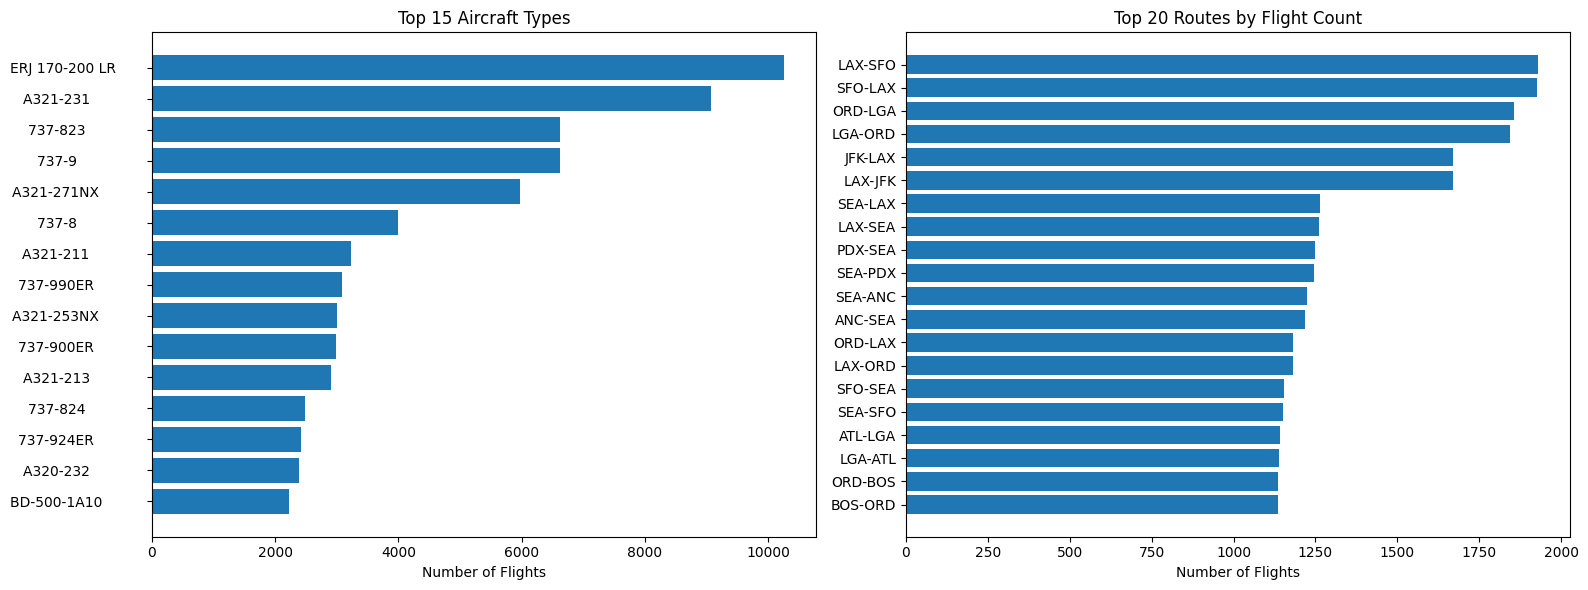

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Aircraft type distribution
acft_counts = df['ACFT MODEL'].value_counts().head(15)
axes[0].barh(acft_counts.index[::-1], acft_counts.values[::-1])
axes[0].set_title('Top 15 Aircraft Types')
axes[0].set_xlabel('Number of Flights')

# 2. Route distribution
df['ROUTE'] = df['ORIGIN'] + '-' + df['DEST']
route_counts = df['ROUTE'].value_counts().head(20)
axes[1].barh(route_counts.index[::-1], route_counts.values[::-1])
axes[1].set_title('Top 20 Routes by Flight Count')
axes[1].set_xlabel('Number of Flights')

plt.tight_layout()
plt.show()

In [ ]:
total = len(df)
print(f"Total flights: {total}")
print(f"ACFT MODEL matched: {df['ACFT MODEL'].notna().sum()} ({df['ACFT MODEL'].notna().sum()/total*100:.1f}%)")
print(f"ENG MODEL matched: {df['ENG MODEL'].notna().sum()} ({df['ENG MODEL'].notna().sum()/total*100:.1f}%)")
print(f"Fuel Flow matched: {df['Fuel Flow T/O (kg/sec)'].notna().sum()} ({df['Fuel Flow T/O (kg/sec)'].notna().sum()/total*100:.1f}%)")
print(f"Weather matched: {df['temp_C'].notna().sum()} ({df['temp_C'].notna().sum()/total*100:.1f}%)")
print(f"All matched: {df[['ACFT MODEL', 'ENG MODEL', 'Fuel Flow T/O (kg/sec)', 'temp_C']].notna().all(axis=1).sum()} ({df[['ACFT MODEL', 'ENG MODEL', 'Fuel Flow T/O (kg/sec)', 'temp_C']].notna().all(axis=1).sum()/total*100:.1f}%)")

Total flights: 103343
ACFT MODEL matched: 102857 (99.5%)
ENG MODEL matched: 103343 (100.0%)
Fuel Flow matched: 99640 (96.4%)
Weather matched: 102364 (99.1%)
All matched: 98690 (95.5%)


In [ ]:
df_clean = df[df[['ACFT MODEL', 'ENG MODEL', 'Fuel Flow T/O (kg/sec)', 'temp_C']].notna().all(axis=1)].copy()
print(f"Clean dataset: {df_clean.shape}")

df_clean.to_csv('/content/flights_final.csv', index=False)
print("Saved!")

Clean dataset: (98690, 59)
Saved!


In [ ]:
# Rename existing weather columns
df_clean = df_clean.rename(columns={
    'temp_C': 'orig_temp_C',
    'pressure_hPa': 'orig_pressure_hPa',
    'airport': 'orig_airport',
    'time': 'orig_time'
})

# Convert WHEELS_ON to datetime
df_clean['WHEELS_ON_STR'] = df_clean['WHEELS_ON'].fillna(0).astype(int).astype(str).str.zfill(4)
df_clean['WHEELS_ON_STR'] = df_clean['WHEELS_ON_STR'].str[:2] + ':' + df_clean['WHEELS_ON_STR'].str[2:]
df_clean['WHEELS_ON_STR'] = df_clean['WHEELS_ON_STR'].replace('24:00', '00:00')

df_clean['WHEELS_ON_DT'] = pd.to_datetime(
    df_clean['FL_DATE'].astype(str) + ' ' + df_clean['WHEELS_ON_STR'],
    format='%Y-%m-%d %H:%M'
)

# UTC offset for destination
df_clean['DEST_UTC_OFFSET'] = df_clean['DEST'].map(timezone_map)
df_clean['WHEELS_ON_UTC'] = df_clean['WHEELS_ON_DT'].dt.floor('h') - pd.to_timedelta(df_clean['DEST_UTC_OFFSET'], unit='h')

# Merge destination weather
df_clean = df_clean.merge(weather,
                          left_on=['DEST', 'WHEELS_ON_UTC'],
                          right_on=['airport', 'time'],
                          how='left')

df_clean = df_clean.rename(columns={
    'temp_C': 'dest_temp_C',
    'pressure_hPa': 'dest_pressure_hPa',
    'airport': 'dest_airport',
    'time': 'dest_time'
})

print(f"Dest weather matched: {df_clean['dest_temp_C'].notna().sum()}")

Dest weather matched: 98179


In [ ]:
df_clean = df_clean[df_clean[['ACFT MODEL', 'ENG MODEL', 'Fuel Flow T/O (kg/sec)',
                               'orig_temp_C', 'dest_temp_C']].notna().all(axis=1)].copy()
print(f"Final clean dataset: {df_clean.shape}")

Final clean dataset: (98179, 67)


In [ ]:
print(df_clean['ACFT MFR'].value_counts())

ACFT MFR
BOEING                            46274
AIRBUS                            21302
EMBRAER S A                        6846
AIRBUS INDUSTRIE                   6595
AIRBUS S A S                       3356
AIRBUS SAS                         3173
EMBRAER                            2728
EMBRAER-EMPRESA BRASILEIRA DE      2612
AIRBUS CANADA LP                   1791
AIRBUS CANADA LTD PTNRSP           1294
YABORA INDUSTRIA AERONAUTICA S      849
BOMBARDIER INC                      847
C SERIES AIRCRAFT LTD PTNRSP        497
EMPRESA BRASILEIRA DE AERO S A       15
Name: count, dtype: int64


In [ ]:
mfr_map = {
    'AIRBUS INDUSTRIE': 'AIRBUS',
    'AIRBUS S A S': 'AIRBUS',
    'AIRBUS SAS': 'AIRBUS',
    'AIRBUS CANADA LP': 'AIRBUS',
    'AIRBUS CANADA LTD PTNRSP': 'AIRBUS',
    'C SERIES AIRCRAFT LTD PTNRSP': 'AIRBUS',
    'EMBRAER S A': 'EMBRAER',
    'EMBRAER-EMPRESA BRASILEIRA DE': 'EMBRAER',
    'EMPRESA BRASILEIRA DE AERO S A': 'EMBRAER',
    'YABORA INDUSTRIA AERONAUTICA S': 'EMBRAER',
    'BOMBARDIER INC': 'BOMBARDIER',
}

df_clean['ACFT MFR CLEAN'] = df_clean['ACFT MFR'].replace(mfr_map)
print(df_clean['ACFT MFR CLEAN'].value_counts())

ACFT MFR CLEAN
BOEING                            46274
AIRBUS                            21302
EMBRAER S A                        6846
AIRBUS INDUSTRIE                   6595
AIRBUS S A S                       3356
AIRBUS SAS                         3173
EMBRAER                            2728
EMBRAER-EMPRESA BRASILEIRA DE      2612
AIRBUS CANADA LP                   1791
AIRBUS CANADA LTD PTNRSP           1294
EMBRAER                             864
BOMBARDIER INC                      847
C SERIES AIRCRAFT LTD PTNRSP        497
Name: count, dtype: int64


In [ ]:
df_clean['ACFT MFR'] = df_clean['ACFT MFR'].astype(str).str.strip()
df_clean['ACFT MFR CLEAN'] = df_clean['ACFT MFR'].replace(mfr_map)
print(df_clean['ACFT MFR CLEAN'].value_counts())

ACFT MFR CLEAN
BOEING        46274
AIRBUS        38008
EMBRAER       13050
BOMBARDIER      847
Name: count, dtype: int64


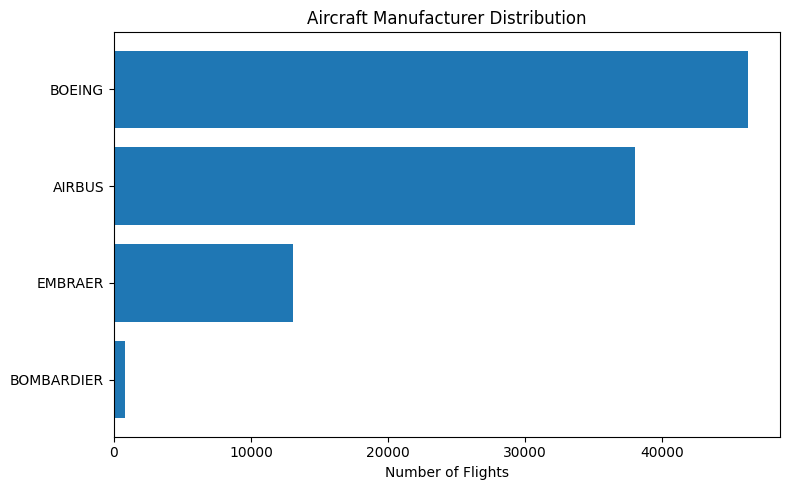

In [ ]:
mfr_counts = df_clean['ACFT MFR CLEAN'].value_counts()
plt.figure(figsize=(8, 5))
plt.barh(mfr_counts.index[::-1], mfr_counts.values[::-1])
plt.title('Aircraft Manufacturer Distribution')
plt.xlabel('Number of Flights')
plt.tight_layout()
plt.show()

In [ ]:
df_clean.to_csv('/content/flights_final.csv', index=False)
print("Saved!")

Saved!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# ============================================================
# STEP 0: Load raw data
# ============================================================

master = pd.read_csv('/content/MASTER.txt', low_memory=False)
eng = pd.read_csv('/content/ENGINE.txt')
acft = pd.read_csv('/content/ACFTREF.txt')
jan_raw = pd.read_csv('/content/T_ONTIME_MARKETING_JAN.csv', low_memory=False)
jul_raw = pd.read_csv('/content/T_ONTIME_MARKETING_JUL.csv', low_memory=False)
gaseous = pd.read_excel('/content/emissions_indices.xlsx', sheet_name='Gaseous Emissions and Smoke')

# ============================================================
# STEP 1: Filter flights by target airports
# ============================================================

target_ids = [
    13796,  # OAK - Oakland International
    14771,  # SFO - San Francisco International
    12892,  # LAX - Los Angeles International
    10800,  # BUR - Burbank Bob Hope
    14057,  # PDX - Portland International
    14747,  # SEA - Seattle/Tacoma International
    12134,  # HNL - Honolulu Daniel K Inouye International
    12173,  # HNL - Honolulu Daniel K Inouye International (alt ID)
    10299,  # ANC - Ted Stevens Anchorage International
    13930,  # ORD - Chicago O'Hare International
    11067,  # CMI - Champaign University of Illinois Willard
    10721,  # BOS - Boston Logan International
    14100,  # PHL - Philadelphia International
    12478,  # JFK - New York John F. Kennedy International
    11618,  # EWR - Newark Liberty International
    12953,  # LGA - New York LaGuardia
    10397,  # ATL - Hartsfield-Jackson Atlanta International
    11298,  # DFW - Dallas/Fort Worth International
    10617,  # BIH - Bishop Airport
    11603,  # EUG - Eugene Mahlon Sweet Field
    11292,  # DEN - Denver International
]

id_to_iata = {
    13796: 'OAK', 14771: 'SFO', 12892: 'LAX', 10800: 'BUR',
    14057: 'PDX', 14747: 'SEA', 12134: 'HNL', 12173: 'HNL',
    10299: 'ANC', 13930: 'ORD', 11067: 'CMI', 10721: 'BOS',
    14100: 'PHL', 12478: 'JFK', 11618: 'EWR', 12953: 'LGA',
    10397: 'ATL', 11298: 'DFW', 10617: 'BIH', 11603: 'EUG',
    11292: 'DEN'
}

filtered_jan = jan_raw[jan_raw['ORIGIN_AIRPORT_ID'].isin(target_ids) & jan_raw['DEST_AIRPORT_ID'].isin(target_ids)].copy()
filtered_jul = jul_raw[jul_raw['ORIGIN_AIRPORT_ID'].isin(target_ids) & jul_raw['DEST_AIRPORT_ID'].isin(target_ids)].copy()

flights = pd.concat([filtered_jan, filtered_jul], ignore_index=True)
flights = flights[flights['CANCELLED'] != 1.0]
print(f"Total flights: {len(flights)}")

# ============================================================
# STEP 2: FAA merge - attach engine model via tail number
# ============================================================

master['N-NUMBER'] = master['N-NUMBER'].astype(str).str.strip()
eng['CODE'] = eng['CODE'].astype(str).str.strip()
acft['CODE'] = acft['CODE'].astype(str).str.strip()

# Merge ENGINE and ACFTREF into master
master = master.merge(eng[['CODE', 'MFR', 'MODEL']], left_on='ENG MFR MDL', right_on='CODE', how='left')
master = master.rename(columns={'MFR': 'ENG MFR', 'MODEL': 'ENG MODEL'})
master = master.drop(columns=['CODE'], errors='ignore')

master = master.merge(acft[['CODE', 'MFR', 'MODEL']], left_on='MFR MDL CODE', right_on='CODE', how='left')
master = master.rename(columns={'MFR': 'ACFT MFR', 'MODEL': 'ACFT MODEL'})
master = master.drop(columns=['CODE'], errors='ignore')

# Merge with flights
flights['TAIL_NUM_CLEAN'] = flights['TAIL_NUM'].str.lstrip('N')
df = flights.merge(master[['N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'ENG MFR', 'ENG MODEL', 'ACFT MFR', 'ACFT MODEL']],
                   left_on='TAIL_NUM_CLEAN', right_on='N-NUMBER', how='left')

print(f"Engine model matched: {df['ENG MODEL'].notna().sum()}")

# ============================================================
# STEP 3: EASA emissions merge
# ============================================================

easa_num_cols = [c for c in gaseous.columns if 'Fuel Flow' in c or 'CO EI' in c or 'NOx EI' in c]
gaseous_med = gaseous.groupby('Engine Identification')[easa_num_cols].median().reset_index()

# Confirmed engine name mapping
confirmed_map = {
    'CFM56 SERIES':    'CFM56-7B27',
    'LEAP-1B28 SER':   'LEAP-1B28',
    'V2500SERIES':     'V2527-A5',
    'RB-211 SERIES':   'RB211-535E4',
    'PW4000 SER':      'PW4056',
    'CF6-80 SERIES':   'CF6-80C2B6',
    'PW1521G SERIE':   'PW1521G',
    'CF34 SERIES':     'CF34-8C5',
    'PW1524G SERIE':   'PW1524G',
    'CFM56-7B27/B3':   'CFM56-7B27/3',
    'CFM56-7B27E/B':   'CFM56-7B27E',
    'GENX-1B70/P2':    'GEnx-1B70/P2',
    'GENX-1B76/P2':    'GEnx-1B76/P2',
    'LEAP-1A33':       'LEAP-1A35A/33/33B2/32/30',
    'LEAP-1A26':       'LEAP-1A26/26E1',
    'LEAP-1B28B':      'LEAP-1B28',
    'GENX-1B74/75/':   'GEnx-1B74/75/P2',
    'RR772B-60':       'RB211-535E4',
    'RB211 772B-60':   'RB211-535E4',
    'LEAP-1B27 SER':   'LEAP-1B28',
    'RB-211-22':       'RB211-22B',
}

df['ENG MODEL'] = df['ENG MODEL'].astype(str).str.strip()
df['ENG MODEL'] = df['ENG MODEL'].replace(confirmed_map)

df = df.merge(gaseous_med, left_on='ENG MODEL', right_on='Engine Identification', how='left')
print(f"Fuel flow matched: {df['Fuel Flow T/O (kg/sec)'].notna().sum()}")

# ============================================================
# STEP 4: Weather data
# ============================================================

airports = {
    'OAK': (37.7213, -122.2208), 'SFO': (37.6213, -122.3790),
    'LAX': (33.9425, -118.4081), 'BUR': (34.2007, -118.3592),
    'PDX': (45.5898, -122.5951), 'SEA': (47.4502, -122.3088),
    'HNL': (21.3245, -157.9251), 'ANC': (61.1743, -149.9963),
    'ORD': (41.9742, -87.9073),  'CMI': (40.0392, -88.2781),
    'BOS': (42.3656, -71.0096),  'PHL': (39.8721, -75.2411),
    'JFK': (40.6413, -73.7781),  'EWR': (40.6895, -74.1745),
    'LGA': (40.7772, -73.8726),  'ATL': (33.6407, -84.4277),
    'DFW': (32.8998, -97.0403),  'BIH': (37.3730, -118.3637),
    'EUG': (44.1246, -123.2190), 'DEN': (39.8561, -104.6737),
}

timezone_map = {
    'OAK': -8, 'SFO': -8, 'LAX': -8, 'BUR': -8, 'PDX': -8, 'SEA': -8,
    'HNL': -10, 'ANC': -9,
    'ORD': -6, 'CMI': -6, 'DEN': -7,
    'BOS': -5, 'PHL': -5, 'JFK': -5, 'EWR': -5, 'LGA': -5,
    'ATL': -5, 'DFW': -6,
    'BIH': -8, 'EUG': -8,
}

def get_weather(iata, lat, lon, start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": start_date, "end_date": end_date,
        "hourly": "temperature_2m,surface_pressure",
        "timezone": "UTC"
    }
    r = requests.get(url, params=params).json()
    return pd.DataFrame({
        'time': r['hourly']['time'],
        'temp_C': r['hourly']['temperature_2m'],
        'pressure_hPa': r['hourly']['surface_pressure'],
        'airport': iata
    })

weather_jan = pd.concat([get_weather(k, v[0], v[1], "2025-01-01", "2025-01-31") for k, v in airports.items()])
weather_jul = pd.concat([get_weather(k, v[0], v[1], "2025-07-01", "2025-07-31") for k, v in airports.items()])
weather = pd.concat([weather_jan, weather_jul], ignore_index=True)
weather['time'] = pd.to_datetime(weather['time'])

# Attach IATA codes
df['ORIGIN'] = df['ORIGIN_AIRPORT_ID'].map(id_to_iata)
df['DEST'] = df['DEST_AIRPORT_ID'].map(id_to_iata)

# Convert WHEELS_OFF to UTC
def to_datetime_safe(date_col, time_col):
    time_str = time_col.fillna(0).astype(int).astype(str).str.zfill(4)
    time_str = time_str.str[:2] + ':' + time_str.str[2:]
    time_str = time_str.replace('24:00', '00:00')
    return pd.to_datetime(date_col.astype(str) + ' ' + time_str, format='%Y-%m-%d %H:%M')

df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['WHEELS_OFF_DT'] = to_datetime_safe(df['FL_DATE'], df['WHEELS_OFF'])
df['WHEELS_ON_DT'] = to_datetime_safe(df['FL_DATE'], df['WHEELS_ON'])

df['WHEELS_OFF_HOUR'] = df['WHEELS_OFF_DT'].dt.floor('h')
df['WHEELS_ON_HOUR'] = df['WHEELS_ON_DT'].dt.floor('h')

df['UTC_OFFSET'] = df['ORIGIN'].map(timezone_map)
df['DEST_UTC_OFFSET'] = df['DEST'].map(timezone_map)
df['WHEELS_OFF_UTC'] = df['WHEELS_OFF_HOUR'] - pd.to_timedelta(df['UTC_OFFSET'], unit='h')
df['WHEELS_ON_UTC'] = df['WHEELS_ON_HOUR'] - pd.to_timedelta(df['DEST_UTC_OFFSET'], unit='h')

# Merge origin weather
df = df.merge(weather, left_on=['ORIGIN', 'WHEELS_OFF_UTC'], right_on=['airport', 'time'], how='left')
df = df.rename(columns={'temp_C': 'orig_temp_C', 'pressure_hPa': 'orig_pressure_hPa', 'airport': 'orig_airport', 'time': 'orig_time'})

# Merge destination weather
df = df.merge(weather, left_on=['DEST', 'WHEELS_ON_UTC'], right_on=['airport', 'time'], how='left')
df = df.rename(columns={'temp_C': 'dest_temp_C', 'pressure_hPa': 'dest_pressure_hPa', 'airport': 'dest_airport', 'time': 'dest_time'})

print(f"Origin weather matched: {df['orig_temp_C'].notna().sum()}")
print(f"Dest weather matched: {df['dest_temp_C'].notna().sum()}")

# ============================================================
# STEP 5: Clean and save
# ============================================================

# Clean manufacturer names
mfr_map = {
    'AIRBUS INDUSTRIE': 'AIRBUS', 'AIRBUS S A S': 'AIRBUS',
    'AIRBUS SAS': 'AIRBUS', 'AIRBUS CANADA LP': 'AIRBUS',
    'AIRBUS CANADA LTD PTNRSP': 'AIRBUS', 'C SERIES AIRCRAFT LTD PTNRSP': 'AIRBUS',
    'EMBRAER S A': 'EMBRAER', 'EMBRAER-EMPRESA BRASILEIRA DE': 'EMBRAER',
    'EMPRESA BRASILEIRA DE AERO S A': 'EMBRAER', 'YABORA INDUSTRIA AERONAUTICA S': 'EMBRAER',
    'BOMBARDIER INC': 'BOMBARDIER',
}
df['ACFT MFR'] = df['ACFT MFR'].astype(str).str.strip()
df['ACFT MFR CLEAN'] = df['ACFT MFR'].replace(mfr_map)

# Route classification
df['ROUTE'] = df['ORIGIN'] + '-' + df['DEST']

def classify_route(distance):
    if distance < 250:
        return 'Short Hopper'
    elif distance < 750:
        return 'Regional'
    elif distance < 1500:
        return 'Medium Haul'
    elif distance < 3000:
        return 'Long Haul'
    else:
        return 'Ultra Long Haul'

def classify_geographic(origin, dest):
    hawaii = {'HNL'}
    alaska = {'ANC'}
    west_coast = {'OAK', 'SFO', 'LAX', 'BUR', 'PDX', 'SEA'}
    east_coast = {'BOS', 'PHL', 'JFK', 'EWR', 'LGA'}
    airports_set = {origin, dest}
    if airports_set & hawaii:
        return 'Hawaii Route'
    elif airports_set & alaska:
        return 'Alaska Route'
    elif (airports_set & west_coast) and (airports_set & east_coast):
        return 'Transcontinental'
    else:
        return 'Domestic'

df['ROUTE_TYPE'] = df['DISTANCE'].apply(classify_route)
df['GEO_TYPE'] = df.apply(lambda x: classify_geographic(x['ORIGIN'], x['DEST']), axis=1)

# Final clean dataset
df_clean = df[df[['ACFT MODEL', 'ENG MODEL', 'Fuel Flow T/O (kg/sec)',
                   'orig_temp_C', 'dest_temp_C']].notna().all(axis=1)].copy()

print(f"Final clean dataset: {df_clean.shape}")
df_clean.to_csv('/content/flights_with_Denver.csv', index=False)
print("Saved!")

Total flights: 125216
Engine model matched: 122387
Fuel flow matched: 120844


/tmp/ipykernel_17114/2632404568.py:182: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])


Origin weather matched: 124032
Dest weather matched: 123728
Final clean dataset: (119087, 66)
Saved!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# ============================================================
# STEP 0: Load raw data
# ============================================================

master  = pd.read_csv('/content/MASTER.txt', low_memory=False)
eng     = pd.read_csv('/content/ENGINE.txt')
acft    = pd.read_csv('/content/ACFTREF.txt')
jan_raw = pd.read_parquet('/content/T_ONTIME_MARKETING_JAN.parquet')
jul_raw = pd.read_parquet('/content/T_ONTIME_MARKETING_JUL.parquet')
gaseous = pd.read_excel('/content/emissions_indices.xlsx', sheet_name='Gaseous Emissions and Smoke')

# ============================================================
# STEP 1: Filter flights by target airports
# ============================================================

target_ids = [
    # --- Original ---
    13796,  # OAK - Oakland International
    14771,  # SFO - San Francisco International
    12892,  # LAX - Los Angeles International
    10800,  # BUR - Burbank Bob Hope
    14057,  # PDX - Portland International
    14747,  # SEA - Seattle/Tacoma International
    12134,  # HNL - Honolulu Daniel K Inouye International
    12173,  # HNL - Honolulu (alt ID)
    10299,  # ANC - Ted Stevens Anchorage International
    13930,  # ORD - Chicago O'Hare International
    11067,  # CMI - Champaign/Willard
    10721,  # BOS - Boston Logan
    14100,  # PHL - Philadelphia International
    12478,  # JFK - New York JFK
    11618,  # EWR - Newark Liberty
    12953,  # LGA - New York LaGuardia
    10397,  # ATL - Hartsfield-Jackson Atlanta
    11298,  # DFW - Dallas/Fort Worth
    10617,  # BIH - Bishop Airport
    11603,  # EUG - Eugene Mahlon Sweet Field
    11292,  # DEN - Denver International
    # --- New ---
    14843,  # SJU - Luis Munoz Marin International (San Juan, PR)
    12278,  # ICT - Wichita Dwight D Eisenhower National
    14685,  # SAV - Savannah/Hilton Head International
    10581,  # BGR - Bangor International
    13204,  # MCO - Orlando International
    13830,  # OGG - Kahului Airport (Maui, HI)
    12758,  # KOA - Ellison Onizuka Kona International
    12906,  # LMK - Lumberton Regional
    10754,  # BRW - Wiley Post/Will Rogers Memorial (Barrow, AK)
    14689,  # SBA - Santa Barbara Municipal
    11413,  # DRO - Durango La Plata County
    14107,  # PHX - Phoenix Sky Harbor International
    11057,  # CLT - Charlotte Douglas International
    10431,  # AVL - Asheville Regional
    12523,  # JNU - Juneau International
    14869,  # SLC - Salt Lake City International
    13127,  # LWS - Lewiston Nez Perce County
    11111,  # COU - Columbia Regional (MO)
    12264,  # IAD - Washington Dulles International
    11278,  # DCA - Ronald Reagan Washington National
]

id_to_iata = {
    # --- Original ---
    13796: 'OAK', 14771: 'SFO', 12892: 'LAX', 10800: 'BUR',
    14057: 'PDX', 14747: 'SEA', 12134: 'HNL', 12173: 'HNL',
    10299: 'ANC', 13930: 'ORD', 11067: 'CMI', 10721: 'BOS',
    14100: 'PHL', 12478: 'JFK', 11618: 'EWR', 12953: 'LGA',
    10397: 'ATL', 11298: 'DFW', 10617: 'BIH', 11603: 'EUG',
    11292: 'DEN',
    # --- New ---
    14843: 'SJU', 12278: 'ICT', 14685: 'SAV', 10581: 'BGR',
    13204: 'MCO', 13830: 'OGG', 12758: 'KOA', 12906: 'LMK',
    10754: 'BRW', 14689: 'SBA', 11413: 'DRO', 14107: 'PHX',
    11057: 'CLT', 10431: 'AVL', 12523: 'JNU', 14869: 'SLC',
    13127: 'LWS', 11111: 'COU', 12264: 'IAD', 11278: 'DCA',
}

filtered_jan = jan_raw[jan_raw['ORIGIN_AIRPORT_ID'].isin(target_ids) & jan_raw['DEST_AIRPORT_ID'].isin(target_ids)].copy()
filtered_jul = jul_raw[jul_raw['ORIGIN_AIRPORT_ID'].isin(target_ids) & jul_raw['DEST_AIRPORT_ID'].isin(target_ids)].copy()

flights = pd.concat([filtered_jan, filtered_jul], ignore_index=True)
flights = flights[flights['CANCELLED'] != 1.0]
print(f"Total flights: {len(flights)}")

# ============================================================
# STEP 2: FAA merge - attach engine model via tail number
# ============================================================

master['N-NUMBER'] = master['N-NUMBER'].astype(str).str.strip()
eng['CODE']  = eng['CODE'].astype(str).str.strip()
acft['CODE'] = acft['CODE'].astype(str).str.strip()

master = master.merge(eng[['CODE', 'MFR', 'MODEL']], left_on='ENG MFR MDL', right_on='CODE', how='left')
master = master.rename(columns={'MFR': 'ENG MFR', 'MODEL': 'ENG MODEL'})
master = master.drop(columns=['CODE'], errors='ignore')

master = master.merge(acft[['CODE', 'MFR', 'MODEL']], left_on='MFR MDL CODE', right_on='CODE', how='left')
master = master.rename(columns={'MFR': 'ACFT MFR', 'MODEL': 'ACFT MODEL'})
master = master.drop(columns=['CODE'], errors='ignore')

flights['TAIL_NUM_CLEAN'] = flights['TAIL_NUM'].str.lstrip('N')
df = flights.merge(
    master[['N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'ENG MFR', 'ENG MODEL', 'ACFT MFR', 'ACFT MODEL']],
    left_on='TAIL_NUM_CLEAN', right_on='N-NUMBER', how='left'
)
print(f"Engine model matched: {df['ENG MODEL'].notna().sum()}")

# ============================================================
# STEP 3: EASA emissions merge
# ============================================================

easa_num_cols = [c for c in gaseous.columns if 'Fuel Flow' in c or 'CO EI' in c or 'NOx EI' in c]
gaseous_med   = gaseous.groupby('Engine Identification')[easa_num_cols].median().reset_index()

confirmed_map = {
    'CFM56 SERIES':    'CFM56-7B27',
    'LEAP-1B28 SER':   'LEAP-1B28',
    'V2500SERIES':     'V2527-A5',
    'RB-211 SERIES':   'RB211-535E4',
    'PW4000 SER':      'PW4056',
    'CF6-80 SERIES':   'CF6-80C2B6',
    'PW1521G SERIE':   'PW1521G',
    'CF34 SERIES':     'CF34-8C5',
    'PW1524G SERIE':   'PW1524G',
    'CFM56-7B27/B3':   'CFM56-7B27/3',
    'CFM56-7B27E/B':   'CFM56-7B27E',
    'GENX-1B70/P2':    'GEnx-1B70/P2',
    'GENX-1B76/P2':    'GEnx-1B76/P2',
    'LEAP-1A33':       'LEAP-1A35A/33/33B2/32/30',
    'LEAP-1A26':       'LEAP-1A26/26E1',
    'LEAP-1B28B':      'LEAP-1B28',
    'GENX-1B74/75/':   'GEnx-1B74/75/P2',
    'RR772B-60':       'RB211-535E4',
    'RB211 772B-60':   'RB211-535E4',
    'LEAP-1B27 SER':   'LEAP-1B28',
    'RB-211-22':       'RB211-22B',
}

df['ENG MODEL'] = df['ENG MODEL'].astype(str).str.strip().replace(confirmed_map)
df = df.merge(gaseous_med, left_on='ENG MODEL', right_on='Engine Identification', how='left')
print(f"Fuel flow matched: {df['Fuel Flow T/O (kg/sec)'].notna().sum()}")

# ============================================================
# STEP 4: Weather data
# ============================================================

airports = {
    # --- Original ---
    'OAK': (37.7213, -122.2208), 'SFO': (37.6213, -122.3790),
    'LAX': (33.9425, -118.4081), 'BUR': (34.2007, -118.3592),
    'PDX': (45.5898, -122.5951), 'SEA': (47.4502, -122.3088),
    'HNL': (21.3245, -157.9251), 'ANC': (61.1743, -149.9963),
    'ORD': (41.9742,  -87.9073), 'CMI': (40.0392,  -88.2781),
    'BOS': (42.3656,  -71.0096), 'PHL': (39.8721,  -75.2411),
    'JFK': (40.6413,  -73.7781), 'EWR': (40.6895,  -74.1745),
    'LGA': (40.7772,  -73.8726), 'ATL': (33.6407,  -84.4277),
    'DFW': (32.8998,  -97.0403), 'BIH': (37.3730, -118.3637),
    'EUG': (44.1246, -123.2190), 'DEN': (39.8561, -104.6737),
    # --- New ---
    'SJU': (18.4394,  -66.0018),  # San Juan, PR
    'ICT': (37.6499,  -97.4331),  # Wichita, KS
    'SAV': (32.1276,  -81.2021),  # Savannah, GA
    'BGR': (44.8074,  -68.8281),  # Bangor, ME
    'MCO': (28.4312,  -81.3081),  # Orlando, FL
    'OGG': (20.8986, -156.4305),  # Kahului, HI
    'KOA': (19.7388, -156.0456),  # Kona, HI
    'LMK': (34.6099,  -79.0594),  # Lumberton, NC
    'BRW': (71.2854, -156.7660),  # Barrow, AK
    'SBA': (34.4262, -119.8401),  # Santa Barbara, CA
    'DRO': (37.1515, -107.7536),  # Durango, CO
    'PHX': (33.4373, -112.0078),  # Phoenix, AZ
    'CLT': (35.2140,  -80.9431),  # Charlotte, NC
    'AVL': (35.4362,  -82.5418),  # Asheville, NC
    'JNU': (58.3549, -134.5763),  # Juneau, AK
    'SLC': (40.7884, -111.9778),  # Salt Lake City, UT
    'LWS': (46.3745, -117.0153),  # Lewiston, ID
    'COU': (38.8181,  -92.2196),  # Columbia, MO
    'IAD': (38.9531,  -77.4565),  # Washington Dulles, VA
    'DCA': (38.8521,  -77.0377),  # Reagan National, VA
}

timezone_map = {
    # --- Original ---
    'OAK': -8, 'SFO': -8, 'LAX': -8, 'BUR': -8, 'PDX': -8, 'SEA': -8,
    'HNL': -10, 'ANC': -9,
    'ORD': -6, 'CMI': -6, 'DEN': -7,
    'BOS': -5, 'PHL': -5, 'JFK': -5, 'EWR': -5, 'LGA': -5,
    'ATL': -5, 'DFW': -6,
    'BIH': -8, 'EUG': -8,
    # --- New ---
    'SJU': -4,   # AST (no DST)
    'ICT': -6,   # CST
    'SAV': -5,   # EST
    'BGR': -5,   # EST
    'MCO': -5,   # EST
    'OGG': -10,  # HST
    'KOA': -10,  # HST
    'LMK': -5,   # EST
    'BRW': -9,   # AKST
    'SBA': -8,   # PST
    'DRO': -7,   # MST
    'PHX': -7,   # MST (no DST)
    'CLT': -5,   # EST
    'AVL': -5,   # EST
    'JNU': -9,   # AKST
    'SLC': -7,   # MST
    'LWS': -8,   # PST
    'COU': -6,   # CST
    'IAD': -5,   # EST
    'DCA': -5,   # EST
}

def get_weather(iata, lat, lon, start_date, end_date):
    url    = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": start_date, "end_date": end_date,
        "hourly": "temperature_2m,surface_pressure",
        "timezone": "UTC"
    }
    r = requests.get(url, params=params).json()
    return pd.DataFrame({
        'time':         r['hourly']['time'],
        'temp_C':       r['hourly']['temperature_2m'],
        'pressure_hPa': r['hourly']['surface_pressure'],
        'airport':      iata
    })

weather_jan = pd.concat([get_weather(k, v[0], v[1], "2025-01-01", "2025-01-31") for k, v in airports.items()])
weather_jul = pd.concat([get_weather(k, v[0], v[1], "2025-07-01", "2025-07-31") for k, v in airports.items()])
weather     = pd.concat([weather_jan, weather_jul], ignore_index=True)
weather['time'] = pd.to_datetime(weather['time'])

df['ORIGIN'] = df['ORIGIN_AIRPORT_ID'].map(id_to_iata)
df['DEST']   = df['DEST_AIRPORT_ID'].map(id_to_iata)

def to_datetime_safe(date_col, time_col):
    time_str = time_col.fillna(0).astype(int).astype(str).str.zfill(4)
    time_str = time_str.str[:2] + ':' + time_str.str[2:]
    time_str = time_str.replace('24:00', '00:00')
    return pd.to_datetime(date_col.astype(str) + ' ' + time_str, format='%Y-%m-%d %H:%M')

df['FL_DATE']       = pd.to_datetime(df['FL_DATE'])
df['WHEELS_OFF_DT'] = to_datetime_safe(df['FL_DATE'], df['WHEELS_OFF'])
df['WHEELS_ON_DT']  = to_datetime_safe(df['FL_DATE'], df['WHEELS_ON'])

df['WHEELS_OFF_HOUR'] = df['WHEELS_OFF_DT'].dt.floor('h')
df['WHEELS_ON_HOUR']  = df['WHEELS_ON_DT'].dt.floor('h')

df['UTC_OFFSET']      = df['ORIGIN'].map(timezone_map)
df['DEST_UTC_OFFSET'] = df['DEST'].map(timezone_map)
df['WHEELS_OFF_UTC']  = df['WHEELS_OFF_HOUR'] - pd.to_timedelta(df['UTC_OFFSET'], unit='h')
df['WHEELS_ON_UTC']   = df['WHEELS_ON_HOUR']  - pd.to_timedelta(df['DEST_UTC_OFFSET'], unit='h')

df = df.merge(weather, left_on=['ORIGIN', 'WHEELS_OFF_UTC'], right_on=['airport', 'time'], how='left')
df = df.rename(columns={'temp_C': 'orig_temp_C', 'pressure_hPa': 'orig_pressure_hPa',
                         'airport': 'orig_airport', 'time': 'orig_time'})

df = df.merge(weather, left_on=['DEST', 'WHEELS_ON_UTC'], right_on=['airport', 'time'], how='left')
df = df.rename(columns={'temp_C': 'dest_temp_C', 'pressure_hPa': 'dest_pressure_hPa',
                         'airport': 'dest_airport', 'time': 'dest_time'})

print(f"Origin weather matched: {df['orig_temp_C'].notna().sum()}")
print(f"Dest weather matched:   {df['dest_temp_C'].notna().sum()}")

# ============================================================
# STEP 5: Clean and save
# ============================================================

mfr_map = {
    'AIRBUS INDUSTRIE': 'AIRBUS', 'AIRBUS S A S': 'AIRBUS',
    'AIRBUS SAS': 'AIRBUS', 'AIRBUS CANADA LP': 'AIRBUS',
    'AIRBUS CANADA LTD PTNRSP': 'AIRBUS', 'C SERIES AIRCRAFT LTD PTNRSP': 'AIRBUS',
    'EMBRAER S A': 'EMBRAER', 'EMBRAER-EMPRESA BRASILEIRA DE': 'EMBRAER',
    'EMPRESA BRASILEIRA DE AERO S A': 'EMBRAER', 'YABORA INDUSTRIA AERONAUTICA S': 'EMBRAER',
    'BOMBARDIER INC': 'BOMBARDIER',
}
df['ACFT MFR']       = df['ACFT MFR'].astype(str).str.strip()
df['ACFT MFR CLEAN'] = df['ACFT MFR'].replace(mfr_map)

df['ROUTE'] = df['ORIGIN'] + '-' + df['DEST']

def classify_route(distance):
    if distance < 250:    return 'Short Hopper'
    elif distance < 750:  return 'Regional'
    elif distance < 1500: return 'Medium Haul'
    elif distance < 3000: return 'Long Haul'
    else:                 return 'Ultra Long Haul'

def classify_geographic(origin, dest):
    hawaii     = {'HNL', 'OGG', 'KOA'}
    alaska     = {'ANC', 'BRW', 'JNU'}
    west_coast = {'OAK', 'SFO', 'LAX', 'BUR', 'PDX', 'SEA', 'SBA', 'LWS'}
    east_coast = {'BOS', 'PHL', 'JFK', 'EWR', 'LGA', 'SAV', 'BGR',
                  'MCO', 'CLT', 'AVL', 'LMK', 'IAD', 'DCA'}
    airports_set = {origin, dest}
    if airports_set & hawaii:                                          return 'Hawaii Route'
    elif airports_set & alaska:                                        return 'Alaska Route'
    elif (airports_set & west_coast) and (airports_set & east_coast): return 'Transcontinental'
    else:                                                              return 'Domestic'

df['ROUTE_TYPE'] = df['DISTANCE'].apply(classify_route)
df['GEO_TYPE']   = df.apply(lambda x: classify_geographic(x['ORIGIN'], x['DEST']), axis=1)

df_clean = df[df[['ACFT MODEL', 'ENG MODEL', 'Fuel Flow T/O (kg/sec)',
                   'orig_temp_C', 'dest_temp_C']].notna().all(axis=1)].copy()

print(f"Final clean dataset: {df_clean.shape}")
df_clean.to_parquet('/content/flights_final.parquet', index=False, engine='pyarrow')
print("Saved!")

Total flights: 264241
Engine model matched: 255276
Fuel flow matched: 247987


/tmp/ipykernel_19513/4011538236.py:249: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['FL_DATE']       = pd.to_datetime(df['FL_DATE'])


Origin weather matched: 261870
Dest weather matched:   261288
Final clean dataset: (244667, 66)
Saved!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# ============================================================
# STEP 0: Load raw data
# ============================================================

master  = pd.read_csv('/content/MASTER.txt', low_memory=False)
eng     = pd.read_csv('/content/ENGINE.txt')
acft    = pd.read_csv('/content/ACFTREF.txt')
jan_raw = pd.read_parquet('/content/T_ONTIME_MARKETING_JAN.parquet')
jul_raw = pd.read_parquet('/content/T_ONTIME_MARKETING_JUL.parquet')
gaseous = pd.read_excel('/content/emissions_indices.xlsx', sheet_name='Gaseous Emissions and Smoke')

# ============================================================
# STEP 1: Filter flights by target airports
# ============================================================

target_ids = [
    # --- Original ---
    13796,  # OAK - Oakland International
    14771,  # SFO - San Francisco International
    12892,  # LAX - Los Angeles International
    10800,  # BUR - Burbank Bob Hope
    14057,  # PDX - Portland International
    14747,  # SEA - Seattle/Tacoma International
    12134,  # HNL - Honolulu Daniel K Inouye International
    12173,  # HNL - Honolulu (alt ID)
    10299,  # ANC - Ted Stevens Anchorage International
    13930,  # ORD - Chicago O'Hare International
    11067,  # CMI - Champaign/Willard
    10721,  # BOS - Boston Logan
    14100,  # PHL - Philadelphia International
    12478,  # JFK - New York JFK
    11618,  # EWR - Newark Liberty
    12953,  # LGA - New York LaGuardia
    10397,  # ATL - Hartsfield-Jackson Atlanta
    11298,  # DFW - Dallas/Fort Worth
    10617,  # BIH - Bishop Airport
    11603,  # EUG - Eugene Mahlon Sweet Field
    11292,  # DEN - Denver International
    # --- New ---
    14843,  # SJU - Luis Munoz Marin International (San Juan, PR)
    12278,  # ICT - Wichita Dwight D Eisenhower National
    14685,  # SAV - Savannah/Hilton Head International
    10581,  # BGR - Bangor International
    13204,  # MCO - Orlando International
    13830,  # OGG - Kahului Airport (Maui, HI)
    12758,  # KOA - Ellison Onizuka Kona International
    13029,  # LNK - Lincoln Airport (NE)
    10754,  # BRW - Wiley Post/Will Rogers Memorial (Barrow, AK)
    14689,  # SBA - Santa Barbara Municipal
    11413,  # DRO - Durango La Plata County
    14107,  # PHX - Phoenix Sky Harbor International
    11057,  # CLT - Charlotte Douglas International
    10431,  # AVL - Asheville Regional
    12523,  # JNU - Juneau International
    14869,  # SLC - Salt Lake City International
    13127,  # LWS - Lewiston Nez Perce County
    11111,  # COU - Columbia Regional (MO)
    12264,  # IAD - Washington Dulles International
    11278,  # DCA - Ronald Reagan Washington National
]

id_to_iata = {
    # --- Original ---
    13796: 'OAK', 14771: 'SFO', 12892: 'LAX', 10800: 'BUR',
    14057: 'PDX', 14747: 'SEA', 12134: 'HNL', 12173: 'HNL',
    10299: 'ANC', 13930: 'ORD', 11067: 'CMI', 10721: 'BOS',
    14100: 'PHL', 12478: 'JFK', 11618: 'EWR', 12953: 'LGA',
    10397: 'ATL', 11298: 'DFW', 10617: 'BIH', 11603: 'EUG',
    11292: 'DEN',
    # --- New ---
    14843: 'SJU', 12278: 'ICT', 14685: 'SAV', 10581: 'BGR',
    13204: 'MCO', 13830: 'OGG', 12758: 'KOA', 13029: 'LNK',
    10754: 'BRW', 14689: 'SBA', 11413: 'DRO', 14107: 'PHX',
    11057: 'CLT', 10431: 'AVL', 12523: 'JNU', 14869: 'SLC',
    13127: 'LWS', 11111: 'COU', 12264: 'IAD', 11278: 'DCA',
}

filtered_jan = jan_raw[jan_raw['ORIGIN_AIRPORT_ID'].isin(target_ids) & jan_raw['DEST_AIRPORT_ID'].isin(target_ids)].copy()
filtered_jul = jul_raw[jul_raw['ORIGIN_AIRPORT_ID'].isin(target_ids) & jul_raw['DEST_AIRPORT_ID'].isin(target_ids)].copy()

flights = pd.concat([filtered_jan, filtered_jul], ignore_index=True)
flights = flights[flights['CANCELLED'] != 1.0]
print(f"Total flights: {len(flights)}")

# ============================================================
# STEP 2: FAA merge - attach engine model via tail number
# ============================================================

master['N-NUMBER'] = master['N-NUMBER'].astype(str).str.strip()
eng['CODE']  = eng['CODE'].astype(str).str.strip()
acft['CODE'] = acft['CODE'].astype(str).str.strip()

master = master.merge(eng[['CODE', 'MFR', 'MODEL']], left_on='ENG MFR MDL', right_on='CODE', how='left')
master = master.rename(columns={'MFR': 'ENG MFR', 'MODEL': 'ENG MODEL'})
master = master.drop(columns=['CODE'], errors='ignore')

master = master.merge(acft[['CODE', 'MFR', 'MODEL']], left_on='MFR MDL CODE', right_on='CODE', how='left')
master = master.rename(columns={'MFR': 'ACFT MFR', 'MODEL': 'ACFT MODEL'})
master = master.drop(columns=['CODE'], errors='ignore')

flights['TAIL_NUM_CLEAN'] = flights['TAIL_NUM'].str.lstrip('N')
df = flights.merge(
    master[['N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'ENG MFR', 'ENG MODEL', 'ACFT MFR', 'ACFT MODEL']],
    left_on='TAIL_NUM_CLEAN', right_on='N-NUMBER', how='left'
)
print(f"Engine model matched: {df['ENG MODEL'].notna().sum()}")

# ============================================================
# STEP 3: EASA emissions merge
# ============================================================

easa_num_cols = [c for c in gaseous.columns if 'Fuel Flow' in c or 'CO EI' in c or 'NOx EI' in c]
gaseous_med   = gaseous.groupby('Engine Identification')[easa_num_cols].median().reset_index()

confirmed_map = {
    'CFM56 SERIES':    'CFM56-7B27',
    'LEAP-1B28 SER':   'LEAP-1B28',
    'V2500SERIES':     'V2527-A5',
    'RB-211 SERIES':   'RB211-535E4',
    'PW4000 SER':      'PW4056',
    'CF6-80 SERIES':   'CF6-80C2B6',
    'PW1521G SERIE':   'PW1521G',
    'CF34 SERIES':     'CF34-8C5',
    'PW1524G SERIE':   'PW1524G',
    'CFM56-7B27/B3':   'CFM56-7B27/3',
    'CFM56-7B27E/B':   'CFM56-7B27E',
    'GENX-1B70/P2':    'GEnx-1B70/P2',
    'GENX-1B76/P2':    'GEnx-1B76/P2',
    'LEAP-1A33':       'LEAP-1A35A/33/33B2/32/30',
    'LEAP-1A26':       'LEAP-1A26/26E1',
    'LEAP-1B28B':      'LEAP-1B28',
    'GENX-1B74/75/':   'GEnx-1B74/75/P2',
    'RR772B-60':       'RB211-535E4',
    'RB211 772B-60':   'RB211-535E4',
    'LEAP-1B27 SER':   'LEAP-1B28',
    'RB-211-22':       'RB211-22B',
}

df['ENG MODEL'] = df['ENG MODEL'].astype(str).str.strip().replace(confirmed_map)
df = df.merge(gaseous_med, left_on='ENG MODEL', right_on='Engine Identification', how='left')
print(f"Fuel flow matched: {df['Fuel Flow T/O (kg/sec)'].notna().sum()}")

# ============================================================
# STEP 4: Weather data
# ============================================================

airports = {
    # --- Original ---
    'OAK': (37.7213, -122.2208), 'SFO': (37.6213, -122.3790),
    'LAX': (33.9425, -118.4081), 'BUR': (34.2007, -118.3592),
    'PDX': (45.5898, -122.5951), 'SEA': (47.4502, -122.3088),
    'HNL': (21.3245, -157.9251), 'ANC': (61.1743, -149.9963),
    'ORD': (41.9742,  -87.9073), 'CMI': (40.0392,  -88.2781),
    'BOS': (42.3656,  -71.0096), 'PHL': (39.8721,  -75.2411),
    'JFK': (40.6413,  -73.7781), 'EWR': (40.6895,  -74.1745),
    'LGA': (40.7772,  -73.8726), 'ATL': (33.6407,  -84.4277),
    'DFW': (32.8998,  -97.0403), 'BIH': (37.3730, -118.3637),
    'EUG': (44.1246, -123.2190), 'DEN': (39.8561, -104.6737),
    # --- New ---
    'SJU': (18.4394,  -66.0018),  # San Juan, PR
    'ICT': (37.6499,  -97.4331),  # Wichita, KS
    'SAV': (32.1276,  -81.2021),  # Savannah, GA
    'BGR': (44.8074,  -68.8281),  # Bangor, ME
    'MCO': (28.4312,  -81.3081),  # Orlando, FL
    'OGG': (20.8986, -156.4305),  # Kahului, HI
    'KOA': (19.7388, -156.0456),  # Kona, HI
    'LNK': (40.8510,  -96.7592),  # Lincoln, NE
    'BRW': (71.2854, -156.7660),  # Barrow, AK
    'SBA': (34.4262, -119.8401),  # Santa Barbara, CA
    'DRO': (37.1515, -107.7536),  # Durango, CO
    'PHX': (33.4373, -112.0078),  # Phoenix, AZ
    'CLT': (35.2140,  -80.9431),  # Charlotte, NC
    'AVL': (35.4362,  -82.5418),  # Asheville, NC
    'JNU': (58.3549, -134.5763),  # Juneau, AK
    'SLC': (40.7884, -111.9778),  # Salt Lake City, UT
    'LWS': (46.3745, -117.0153),  # Lewiston, ID
    'COU': (38.8181,  -92.2196),  # Columbia, MO
    'IAD': (38.9531,  -77.4565),  # Washington Dulles, VA
    'DCA': (38.8521,  -77.0377),  # Reagan National, VA
}

timezone_map = {
    # --- Original ---
    'OAK': -8, 'SFO': -8, 'LAX': -8, 'BUR': -8, 'PDX': -8, 'SEA': -8,
    'HNL': -10, 'ANC': -9,
    'ORD': -6, 'CMI': -6, 'DEN': -7,
    'BOS': -5, 'PHL': -5, 'JFK': -5, 'EWR': -5, 'LGA': -5,
    'ATL': -5, 'DFW': -6,
    'BIH': -8, 'EUG': -8,
    # --- New ---
    'SJU': -4,   # AST (no DST)
    'ICT': -6,   # CST
    'SAV': -5,   # EST
    'BGR': -5,   # EST
    'MCO': -5,   # EST
    'OGG': -10,  # HST
    'KOA': -10,  # HST
    'LNK': -6,   # CST
    'BRW': -9,   # AKST
    'SBA': -8,   # PST
    'DRO': -7,   # MST
    'PHX': -7,   # MST (no DST)
    'CLT': -5,   # EST
    'AVL': -5,   # EST
    'JNU': -9,   # AKST
    'SLC': -7,   # MST
    'LWS': -8,   # PST
    'COU': -6,   # CST
    'IAD': -5,   # EST
    'DCA': -5,   # EST
}

def get_weather(iata, lat, lon, start_date, end_date):
    url    = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": start_date, "end_date": end_date,
        "hourly": "temperature_2m,surface_pressure",
        "timezone": "UTC"
    }
    r = requests.get(url, params=params).json()
    return pd.DataFrame({
        'time':         r['hourly']['time'],
        'temp_C':       r['hourly']['temperature_2m'],
        'pressure_hPa': r['hourly']['surface_pressure'],
        'airport':      iata
    })

weather_jan = pd.concat([get_weather(k, v[0], v[1], "2025-01-01", "2025-01-31") for k, v in airports.items()])
weather_jul = pd.concat([get_weather(k, v[0], v[1], "2025-07-01", "2025-07-31") for k, v in airports.items()])
weather     = pd.concat([weather_jan, weather_jul], ignore_index=True)
weather['time'] = pd.to_datetime(weather['time'])

df['ORIGIN'] = df['ORIGIN_AIRPORT_ID'].map(id_to_iata)
df['DEST']   = df['DEST_AIRPORT_ID'].map(id_to_iata)

def to_datetime_safe(date_col, time_col):
    time_str = time_col.fillna(0).astype(int).astype(str).str.zfill(4)
    time_str = time_str.str[:2] + ':' + time_str.str[2:]
    time_str = time_str.replace('24:00', '00:00')
    return pd.to_datetime(date_col.astype(str) + ' ' + time_str, format='%Y-%m-%d %H:%M')

df['FL_DATE']       = pd.to_datetime(df['FL_DATE'])
df['WHEELS_OFF_DT'] = to_datetime_safe(df['FL_DATE'], df['WHEELS_OFF'])
df['WHEELS_ON_DT']  = to_datetime_safe(df['FL_DATE'], df['WHEELS_ON'])

df['WHEELS_OFF_HOUR'] = df['WHEELS_OFF_DT'].dt.floor('h')
df['WHEELS_ON_HOUR']  = df['WHEELS_ON_DT'].dt.floor('h')

df['UTC_OFFSET']      = df['ORIGIN'].map(timezone_map)
df['DEST_UTC_OFFSET'] = df['DEST'].map(timezone_map)
df['WHEELS_OFF_UTC']  = df['WHEELS_OFF_HOUR'] - pd.to_timedelta(df['UTC_OFFSET'], unit='h')
df['WHEELS_ON_UTC']   = df['WHEELS_ON_HOUR']  - pd.to_timedelta(df['DEST_UTC_OFFSET'], unit='h')

df = df.merge(weather, left_on=['ORIGIN', 'WHEELS_OFF_UTC'], right_on=['airport', 'time'], how='left')
df = df.rename(columns={'temp_C': 'orig_temp_C', 'pressure_hPa': 'orig_pressure_hPa',
                         'airport': 'orig_airport', 'time': 'orig_time'})

df = df.merge(weather, left_on=['DEST', 'WHEELS_ON_UTC'], right_on=['airport', 'time'], how='left')
df = df.rename(columns={'temp_C': 'dest_temp_C', 'pressure_hPa': 'dest_pressure_hPa',
                         'airport': 'dest_airport', 'time': 'dest_time'})

print(f"Origin weather matched: {df['orig_temp_C'].notna().sum()}")
print(f"Dest weather matched:   {df['dest_temp_C'].notna().sum()}")

# ============================================================
# STEP 5: Clean and save
# ============================================================

mfr_map = {
    'AIRBUS INDUSTRIE': 'AIRBUS', 'AIRBUS S A S': 'AIRBUS',
    'AIRBUS SAS': 'AIRBUS', 'AIRBUS CANADA LP': 'AIRBUS',
    'AIRBUS CANADA LTD PTNRSP': 'AIRBUS', 'C SERIES AIRCRAFT LTD PTNRSP': 'AIRBUS',
    'EMBRAER S A': 'EMBRAER', 'EMBRAER-EMPRESA BRASILEIRA DE': 'EMBRAER',
    'EMPRESA BRASILEIRA DE AERO S A': 'EMBRAER', 'YABORA INDUSTRIA AERONAUTICA S': 'EMBRAER',
    'BOMBARDIER INC': 'BOMBARDIER',
}
df['ACFT MFR']       = df['ACFT MFR'].astype(str).str.strip()
df['ACFT MFR CLEAN'] = df['ACFT MFR'].replace(mfr_map)

df['ROUTE'] = df['ORIGIN'] + '-' + df['DEST']

def classify_route(distance):
    if distance < 250:    return 'Short Hopper'
    elif distance < 750:  return 'Regional'
    elif distance < 1500: return 'Medium Haul'
    elif distance < 3000: return 'Long Haul'
    else:                 return 'Ultra Long Haul'

def classify_geographic(origin, dest):
    hawaii     = {'HNL', 'OGG', 'KOA'}
    alaska     = {'ANC', 'BRW', 'JNU'}
    west_coast = {'OAK', 'SFO', 'LAX', 'BUR', 'PDX', 'SEA', 'SBA', 'LWS'}
    east_coast = {'BOS', 'PHL', 'JFK', 'EWR', 'LGA', 'SAV', 'BGR',
                  'MCO', 'CLT', 'AVL', 'IAD', 'DCA'}
    airports_set = {origin, dest}
    if airports_set & hawaii:                                          return 'Hawaii Route'
    elif airports_set & alaska:                                        return 'Alaska Route'
    elif (airports_set & west_coast) and (airports_set & east_coast): return 'Transcontinental'
    else:                                                              return 'Domestic'

df['ROUTE_TYPE'] = df['DISTANCE'].apply(classify_route)
df['GEO_TYPE']   = df.apply(lambda x: classify_geographic(x['ORIGIN'], x['DEST']), axis=1)

df_clean = df[df[['ACFT MODEL', 'ENG MODEL', 'Fuel Flow T/O (kg/sec)',
                   'orig_temp_C', 'dest_temp_C']].notna().all(axis=1)].copy()

print(f"Final clean dataset: {df_clean.shape}")
df_clean.to_parquet('/content/flights_final.parquet', index=False, engine='pyarrow')
print("Saved!")

Total flights: 265227
Engine model matched: 256219
Fuel flow matched: 248930


/tmp/ipykernel_8783/3033772266.py:249: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['FL_DATE']       = pd.to_datetime(df['FL_DATE'])


Origin weather matched: 262848
Dest weather matched:   262265
Final clean dataset: (245601, 66)
Saved!


In [ ]:
# ============================================================
# DIAGNOSTIC: 매칭 실패 분석
# ============================================================

# 1) Engine model 미매칭 - 어떤 tail number가 문제인지
no_eng = df[df['ENG MODEL'].isna() | (df['ENG MODEL'] == 'nan')]
print(f"Engine 미매칭: {len(no_eng)}편")
print(no_eng['TAIL_NUM'].value_counts().head(20))

# 2) Fuel flow 미매칭 - 어떤 엔진 모델이 EASA DB에 없는지
no_fuel = df[df['Fuel Flow T/O (kg/sec)'].isna() & df['ENG MODEL'].notna()]
print(f"\nFuel flow 미매칭: {len(no_fuel)}편")
print(no_fuel['ENG MODEL'].value_counts().head(20))

Engine 미매칭: 9008편
TAIL_NUM
N478HA    294
N483HA    292
N475HA    279
N477HA    277
N480HA    270
N476HA    225
N479HA    145
N540DE    115
N942AK    103
N309AS    103
N971UY    103
N129DU     98
N705TW     95
N513DA     94
N880RW     92
N194UW     91
N334JB     90
N140DU     89
N17529     86
N302DU     84
Name: count, dtype: int64

Fuel flow 미매칭: 16297편
ENG MODEL
nan              9008
BR 700 SERIES    2820
BR700-715A130     811
AE3007 SER        560
UNKNOWN ENG       463
BR700-715C1-3     298
CFM56-5B6         259
RB211535E4B37     187
CFM56-5B7         165
PW1500G SER       150
CFM56-7B27/B1     149
GENX-1B75/P2      148
DART RDA-10       139
TRENT 772B-60     121
CFM56-7B          116
GENX-1B76A/P2     114
GENX SERIES       105
CFM56-3B          105
PT6A-66 SER        93
CFM56-5C4/1        60
Name: count, dtype: int64


In [ ]:
# Hawaiian 계열 샘플 확인
sample = no_eng[no_eng['TAIL_NUM'].str.contains('HA|AK|DU', na=False)].head(5)
print(sample[['TAIL_NUM', 'TAIL_NUM_CLEAN', 'N-NUMBER']].to_string())

# MASTER에서 직접 검색
print(master[master['N-NUMBER'].str.startswith('478')].head(3))

     TAIL_NUM TAIL_NUM_CLEAN N-NUMBER
835    N251AK          251AK    251AK
836    N251AK          251AK    251AK
1079   N921AK          921AK    921AK
1093   N942AK          942AK    942AK
1377   N102DU          102DU    102DU
       N-NUMBER                   SERIAL NUMBER MFR MDL CODE ENG MFR MDL  \
142955    47803  8163AE                              3371604       26003   
142956    47805  28R-7803016                         7102813       17019   
142957    47808  15283253                            2071835       41505   

       YEAR MFR TYPE REGISTRANT  \
142955     1943               3   
142956                        7   
142957     1979               7   

                                                     NAME  \
142955  YANKS AIR MUSEUM                              ...   
142956  PREMIER AVIATION LLC                          ...   
142957  COLGAN AVIATION LLC                           ...   

                                   STREET                            STREET2  \
1

In [ ]:
easa_engines = gaseous_med['Engine Identification'].sort_values().tolist()

# 미매칭 엔진명 후보들이 EASA DB에 있는지 검색
candidates = ['BR700-715A1-30', 'BR700-715C1-30', 'AE3007A1', 'AE3007A',
              'RB211-535E4B', 'Trent 772B-60', 'CFM56-7B27/B1',
              'CFM56-5B6/P', 'CFM56-5B7/P', 'CFM56-5C4/1', 'CFM56-3B1',
              'GEnx-1B75/P2', 'GEnx-1B76A/P2', 'PW1521G']

for c in candidates:
    found = [e for e in easa_engines if c.lower() in e.lower()]
    print(f"{c:25s} → {found}")

BR700-715A1-30            → ['BR700-715A1-30']
BR700-715C1-30            → ['BR700-715C1-30']
AE3007A1                  → ['AE3007A1', 'AE3007A1 series', 'AE3007A1/1', 'AE3007A1/3', 'AE3007A1E', 'AE3007A1P']
AE3007A                   → ['AE3007A', 'AE3007A1', 'AE3007A1 series', 'AE3007A1/1', 'AE3007A1/3', 'AE3007A1E', 'AE3007A1P', 'AE3007A2', 'AE3007A3']
RB211-535E4B              → ['RB211-535E4B']
Trent 772B-60             → []
CFM56-7B27/B1             → []
CFM56-5B6/P               → ['CFM56-5B6/P']
CFM56-5B7/P               → ['CFM56-5B7/P']
CFM56-5C4/1               → []
CFM56-3B1                 → []
GEnx-1B75/P2              → ['GEnx-1B75/P2']
GEnx-1B76A/P2             → ['GEnx-1B76A/P2', 'GEnx-1B76A/P2, 1B76/P2']
PW1521G                   → ['PW1521G', 'PW1521GA']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# ============================================================
# STEP 0: Load raw data
# ============================================================

master  = pd.read_csv('/content/MASTER.txt', low_memory=False)
eng     = pd.read_csv('/content/ENGINE.txt')
acft    = pd.read_csv('/content/ACFTREF.txt')
jan_raw = pd.read_parquet('/content/T_ONTIME_MARKETING_JAN.parquet')
jul_raw = pd.read_parquet('/content/T_ONTIME_MARKETING_JUL.parquet')
gaseous = pd.read_excel('/content/emissions_indices.xlsx', sheet_name='Gaseous Emissions and Smoke')

# ============================================================
# STEP 1: Filter flights by target airports
# ============================================================

target_ids = [
    # --- Original ---
    13796,  # OAK - Oakland International
    14771,  # SFO - San Francisco International
    12892,  # LAX - Los Angeles International
    10800,  # BUR - Burbank Bob Hope
    14057,  # PDX - Portland International
    14747,  # SEA - Seattle/Tacoma International
    12134,  # HNL - Honolulu Daniel K Inouye International
    12173,  # HNL - Honolulu (alt ID)
    10299,  # ANC - Ted Stevens Anchorage International
    13930,  # ORD - Chicago O'Hare International
    11067,  # CMI - Champaign/Willard
    10721,  # BOS - Boston Logan
    14100,  # PHL - Philadelphia International
    12478,  # JFK - New York JFK
    11618,  # EWR - Newark Liberty
    12953,  # LGA - New York LaGuardia
    10397,  # ATL - Hartsfield-Jackson Atlanta
    11298,  # DFW - Dallas/Fort Worth
    10617,  # BIH - Bishop Airport
    11603,  # EUG - Eugene Mahlon Sweet Field
    11292,  # DEN - Denver International
    # --- New ---
    14843,  # SJU - Luis Munoz Marin International (San Juan, PR)
    12278,  # ICT - Wichita Dwight D Eisenhower National
    14685,  # SAV - Savannah/Hilton Head International
    10581,  # BGR - Bangor International
    13204,  # MCO - Orlando International
    13830,  # OGG - Kahului Airport (Maui, HI)
    12758,  # KOA - Ellison Onizuka Kona International
    13029,  # LNK - Lincoln Airport (NE)
    10754,  # BRW - Wiley Post/Will Rogers Memorial (Barrow, AK)
    14689,  # SBA - Santa Barbara Municipal
    11413,  # DRO - Durango La Plata County
    14107,  # PHX - Phoenix Sky Harbor International
    11057,  # CLT - Charlotte Douglas International
    10431,  # AVL - Asheville Regional
    12523,  # JNU - Juneau International
    14869,  # SLC - Salt Lake City International
    13127,  # LWS - Lewiston Nez Perce County
    11111,  # COU - Columbia Regional (MO)
    12264,  # IAD - Washington Dulles International
    11278,  # DCA - Ronald Reagan Washington National
]

id_to_iata = {
    # --- Original ---
    13796: 'OAK', 14771: 'SFO', 12892: 'LAX', 10800: 'BUR',
    14057: 'PDX', 14747: 'SEA', 12134: 'HNL', 12173: 'HNL',
    10299: 'ANC', 13930: 'ORD', 11067: 'CMI', 10721: 'BOS',
    14100: 'PHL', 12478: 'JFK', 11618: 'EWR', 12953: 'LGA',
    10397: 'ATL', 11298: 'DFW', 10617: 'BIH', 11603: 'EUG',
    11292: 'DEN',
    # --- New ---
    14843: 'SJU', 12278: 'ICT', 14685: 'SAV', 10581: 'BGR',
    13204: 'MCO', 13830: 'OGG', 12758: 'KOA', 13029: 'LNK',
    10754: 'BRW', 14689: 'SBA', 11413: 'DRO', 14107: 'PHX',
    11057: 'CLT', 10431: 'AVL', 12523: 'JNU', 14869: 'SLC',
    13127: 'LWS', 11111: 'COU', 12264: 'IAD', 11278: 'DCA',
}

filtered_jan = jan_raw[jan_raw['ORIGIN_AIRPORT_ID'].isin(target_ids) & jan_raw['DEST_AIRPORT_ID'].isin(target_ids)].copy()
filtered_jul = jul_raw[jul_raw['ORIGIN_AIRPORT_ID'].isin(target_ids) & jul_raw['DEST_AIRPORT_ID'].isin(target_ids)].copy()

flights = pd.concat([filtered_jan, filtered_jul], ignore_index=True)
flights = flights[flights['CANCELLED'] != 1.0]
print(f"Total flights: {len(flights)}")

# ============================================================
# STEP 2: FAA merge - attach engine model via tail number
# ============================================================

master['N-NUMBER'] = master['N-NUMBER'].astype(str).str.strip()
eng['CODE']  = eng['CODE'].astype(str).str.strip()
acft['CODE'] = acft['CODE'].astype(str).str.strip()

master = master.merge(eng[['CODE', 'MFR', 'MODEL']], left_on='ENG MFR MDL', right_on='CODE', how='left')
master = master.rename(columns={'MFR': 'ENG MFR', 'MODEL': 'ENG MODEL'})
master = master.drop(columns=['CODE'], errors='ignore')

master = master.merge(acft[['CODE', 'MFR', 'MODEL']], left_on='MFR MDL CODE', right_on='CODE', how='left')
master = master.rename(columns={'MFR': 'ACFT MFR', 'MODEL': 'ACFT MODEL'})
master = master.drop(columns=['CODE'], errors='ignore')

flights['TAIL_NUM_CLEAN'] = flights['TAIL_NUM'].str.lstrip('N')
df = flights.merge(
    master[['N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'ENG MFR', 'ENG MODEL', 'ACFT MFR', 'ACFT MODEL']],
    left_on='TAIL_NUM_CLEAN', right_on='N-NUMBER', how='left'
)
print(f"Engine model matched: {df['ENG MODEL'].notna().sum()}")

# ============================================================
# STEP 3: EASA emissions merge
# ============================================================

easa_num_cols = [c for c in gaseous.columns if 'Fuel Flow' in c or 'CO EI' in c or 'NOx EI' in c]
gaseous_med   = gaseous.groupby('Engine Identification')[easa_num_cols].median().reset_index()

confirmed_map = {
    # --- Original ---
    'CFM56 SERIES':    'CFM56-7B27',
    'LEAP-1B28 SER':   'LEAP-1B28',
    'V2500SERIES':     'V2527-A5',
    'RB-211 SERIES':   'RB211-535E4',
    'PW4000 SER':      'PW4056',
    'CF6-80 SERIES':   'CF6-80C2B6',
    'PW1521G SERIE':   'PW1521G',
    'CF34 SERIES':     'CF34-8C5',
    'PW1524G SERIE':   'PW1524G',
    'CFM56-7B27/B3':   'CFM56-7B27/3',
    'CFM56-7B27E/B':   'CFM56-7B27E',
    'GENX-1B70/P2':    'GEnx-1B70/P2',
    'GENX-1B76/P2':    'GEnx-1B76/P2',
    'LEAP-1A33':       'LEAP-1A35A/33/33B2/32/30',
    'LEAP-1A26':       'LEAP-1A26/26E1',
    'LEAP-1B28B':      'LEAP-1B28',
    'GENX-1B74/75/':   'GEnx-1B74/75/P2',
    'RR772B-60':       'RB211-535E4',
    'RB211 772B-60':   'RB211-535E4',
    'LEAP-1B27 SER':   'LEAP-1B28',
    'RB-211-22':       'RB211-22B',
    # --- New: EASA DB 확인 후 추가 ---
    'BR 700 SERIES':   'BR700-715A1-30',   # CRJ-700 대표 엔진
    'BR700-715A130':   'BR700-715A1-30',   # 하이픈 포맷 차이
    'BR700-715C1-3':   'BR700-715C1-30',   # CRJ-900
    'AE3007 SER':      'AE3007A1',          # ERJ-145
    'RB211535E4B37':   'RB211-535E4B',     # 757 (하이픈 누락)
    'CFM56-5B6':       'CFM56-5B6/P',      # A320 계열
    'CFM56-5B7':       'CFM56-5B7/P',      # A320 계열
    'CFM56-7B27/B1':   'CFM56-7B27',       # 737 (가장 가까운 variant로 근사)
    'GENX-1B75/P2':    'GEnx-1B75/P2',    # 787
    'GENX-1B76A/P2':   'GEnx-1B76A/P2',   # 787
    'GENX SERIES':     'GEnx-1B70/P2',     # 787 generic → 대표 variant
    'PW1500G SER':     'PW1521G',           # A220
    # 'TRENT 772B-60' → EASA DB 없음 (777) → drop
    # 'CFM56-5C4/1'   → EASA DB 없음 (A340) → drop
    # 'CFM56-3B'      → EASA DB 없음 (737 Classic) → drop
    # 'DART RDA-10'   → 구형 터보프롭 → drop
    # 'PT6A-66 SER'   → 터보프롭 → drop
    # 'UNKNOWN ENG'   → 불명 → drop
}

df['ENG MODEL'] = df['ENG MODEL'].astype(str).str.strip().replace(confirmed_map)
df = df.merge(gaseous_med, left_on='ENG MODEL', right_on='Engine Identification', how='left')
print(f"Fuel flow matched: {df['Fuel Flow T/O (kg/sec)'].notna().sum()}")

# ============================================================
# STEP 4: Weather data
# ============================================================

airports = {
    # --- Original ---
    'OAK': (37.7213, -122.2208), 'SFO': (37.6213, -122.3790),
    'LAX': (33.9425, -118.4081), 'BUR': (34.2007, -118.3592),
    'PDX': (45.5898, -122.5951), 'SEA': (47.4502, -122.3088),
    'HNL': (21.3245, -157.9251), 'ANC': (61.1743, -149.9963),
    'ORD': (41.9742,  -87.9073), 'CMI': (40.0392,  -88.2781),
    'BOS': (42.3656,  -71.0096), 'PHL': (39.8721,  -75.2411),
    'JFK': (40.6413,  -73.7781), 'EWR': (40.6895,  -74.1745),
    'LGA': (40.7772,  -73.8726), 'ATL': (33.6407,  -84.4277),
    'DFW': (32.8998,  -97.0403), 'BIH': (37.3730, -118.3637),
    'EUG': (44.1246, -123.2190), 'DEN': (39.8561, -104.6737),
    # --- New ---
    'SJU': (18.4394,  -66.0018),  # San Juan, PR
    'ICT': (37.6499,  -97.4331),  # Wichita, KS
    'SAV': (32.1276,  -81.2021),  # Savannah, GA
    'BGR': (44.8074,  -68.8281),  # Bangor, ME
    'MCO': (28.4312,  -81.3081),  # Orlando, FL
    'OGG': (20.8986, -156.4305),  # Kahului, HI
    'KOA': (19.7388, -156.0456),  # Kona, HI
    'LNK': (40.8510,  -96.7592),  # Lincoln, NE
    'BRW': (71.2854, -156.7660),  # Barrow, AK
    'SBA': (34.4262, -119.8401),  # Santa Barbara, CA
    'DRO': (37.1515, -107.7536),  # Durango, CO
    'PHX': (33.4373, -112.0078),  # Phoenix, AZ
    'CLT': (35.2140,  -80.9431),  # Charlotte, NC
    'AVL': (35.4362,  -82.5418),  # Asheville, NC
    'JNU': (58.3549, -134.5763),  # Juneau, AK
    'SLC': (40.7884, -111.9778),  # Salt Lake City, UT
    'LWS': (46.3745, -117.0153),  # Lewiston, ID
    'COU': (38.8181,  -92.2196),  # Columbia, MO
    'IAD': (38.9531,  -77.4565),  # Washington Dulles, VA
    'DCA': (38.8521,  -77.0377),  # Reagan National, VA
}

timezone_map = {
    # --- Original ---
    'OAK': -8, 'SFO': -8, 'LAX': -8, 'BUR': -8, 'PDX': -8, 'SEA': -8,
    'HNL': -10, 'ANC': -9,
    'ORD': -6, 'CMI': -6, 'DEN': -7,
    'BOS': -5, 'PHL': -5, 'JFK': -5, 'EWR': -5, 'LGA': -5,
    'ATL': -5, 'DFW': -6,
    'BIH': -8, 'EUG': -8,
    # --- New ---
    'SJU': -4,   # AST (no DST)
    'ICT': -6,   # CST
    'SAV': -5,   # EST
    'BGR': -5,   # EST
    'MCO': -5,   # EST
    'OGG': -10,  # HST
    'KOA': -10,  # HST
    'LNK': -6,   # CST
    'BRW': -9,   # AKST
    'SBA': -8,   # PST
    'DRO': -7,   # MST
    'PHX': -7,   # MST (no DST)
    'CLT': -5,   # EST
    'AVL': -5,   # EST
    'JNU': -9,   # AKST
    'SLC': -7,   # MST
    'LWS': -8,   # PST
    'COU': -6,   # CST
    'IAD': -5,   # EST
    'DCA': -5,   # EST
}

def get_weather(iata, lat, lon, start_date, end_date):
    url    = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": start_date, "end_date": end_date,
        "hourly": "temperature_2m,surface_pressure",
        "timezone": "UTC"
    }
    r = requests.get(url, params=params).json()
    return pd.DataFrame({
        'time':         r['hourly']['time'],
        'temp_C':       r['hourly']['temperature_2m'],
        'pressure_hPa': r['hourly']['surface_pressure'],
        'airport':      iata
    })

weather_jan = pd.concat([get_weather(k, v[0], v[1], "2025-01-01", "2025-01-31") for k, v in airports.items()])
weather_jul = pd.concat([get_weather(k, v[0], v[1], "2025-07-01", "2025-07-31") for k, v in airports.items()])
weather     = pd.concat([weather_jan, weather_jul], ignore_index=True)
weather['time'] = pd.to_datetime(weather['time'])

df['ORIGIN'] = df['ORIGIN_AIRPORT_ID'].map(id_to_iata)
df['DEST']   = df['DEST_AIRPORT_ID'].map(id_to_iata)

def to_datetime_safe(date_col, time_col):
    time_str = time_col.fillna(0).astype(int).astype(str).str.zfill(4)
    time_str = time_str.str[:2] + ':' + time_str.str[2:]
    time_str = time_str.replace('24:00', '00:00')
    return pd.to_datetime(date_col.astype(str) + ' ' + time_str, format='%Y-%m-%d %H:%M')

df['FL_DATE']       = pd.to_datetime(df['FL_DATE'])
df['WHEELS_OFF_DT'] = to_datetime_safe(df['FL_DATE'], df['WHEELS_OFF'])
df['WHEELS_ON_DT']  = to_datetime_safe(df['FL_DATE'], df['WHEELS_ON'])

df['WHEELS_OFF_HOUR'] = df['WHEELS_OFF_DT'].dt.floor('h')
df['WHEELS_ON_HOUR']  = df['WHEELS_ON_DT'].dt.floor('h')

df['UTC_OFFSET']      = df['ORIGIN'].map(timezone_map)
df['DEST_UTC_OFFSET'] = df['DEST'].map(timezone_map)
df['WHEELS_OFF_UTC']  = df['WHEELS_OFF_HOUR'] - pd.to_timedelta(df['UTC_OFFSET'], unit='h')
df['WHEELS_ON_UTC']   = df['WHEELS_ON_HOUR']  - pd.to_timedelta(df['DEST_UTC_OFFSET'], unit='h')

df = df.merge(weather, left_on=['ORIGIN', 'WHEELS_OFF_UTC'], right_on=['airport', 'time'], how='left')
df = df.rename(columns={'temp_C': 'orig_temp_C', 'pressure_hPa': 'orig_pressure_hPa',
                         'airport': 'orig_airport', 'time': 'orig_time'})

df = df.merge(weather, left_on=['DEST', 'WHEELS_ON_UTC'], right_on=['airport', 'time'], how='left')
df = df.rename(columns={'temp_C': 'dest_temp_C', 'pressure_hPa': 'dest_pressure_hPa',
                         'airport': 'dest_airport', 'time': 'dest_time'})

print(f"Origin weather matched: {df['orig_temp_C'].notna().sum()}")
print(f"Dest weather matched:   {df['dest_temp_C'].notna().sum()}")

# ============================================================
# STEP 5: Clean and save
# ============================================================

mfr_map = {
    'AIRBUS INDUSTRIE': 'AIRBUS', 'AIRBUS S A S': 'AIRBUS',
    'AIRBUS SAS': 'AIRBUS', 'AIRBUS CANADA LP': 'AIRBUS',
    'AIRBUS CANADA LTD PTNRSP': 'AIRBUS', 'C SERIES AIRCRAFT LTD PTNRSP': 'AIRBUS',
    'EMBRAER S A': 'EMBRAER', 'EMBRAER-EMPRESA BRASILEIRA DE': 'EMBRAER',
    'EMPRESA BRASILEIRA DE AERO S A': 'EMBRAER', 'YABORA INDUSTRIA AERONAUTICA S': 'EMBRAER',
    'BOMBARDIER INC': 'BOMBARDIER',
}
df['ACFT MFR']       = df['ACFT MFR'].astype(str).str.strip()
df['ACFT MFR CLEAN'] = df['ACFT MFR'].replace(mfr_map)

df['ROUTE'] = df['ORIGIN'] + '-' + df['DEST']

def classify_route(distance):
    if distance < 250:    return 'Short Hopper'
    elif distance < 750:  return 'Regional'
    elif distance < 1500: return 'Medium Haul'
    elif distance < 3000: return 'Long Haul'
    else:                 return 'Ultra Long Haul'

def classify_geographic(origin, dest):
    hawaii     = {'HNL', 'OGG', 'KOA'}
    alaska     = {'ANC', 'BRW', 'JNU'}
    west_coast = {'OAK', 'SFO', 'LAX', 'BUR', 'PDX', 'SEA', 'SBA', 'LWS'}
    east_coast = {'BOS', 'PHL', 'JFK', 'EWR', 'LGA', 'SAV', 'BGR',
                  'MCO', 'CLT', 'AVL', 'IAD', 'DCA'}
    airports_set = {origin, dest}
    if airports_set & hawaii:                                          return 'Hawaii Route'
    elif airports_set & alaska:                                        return 'Alaska Route'
    elif (airports_set & west_coast) and (airports_set & east_coast): return 'Transcontinental'
    else:                                                              return 'Domestic'

df['ROUTE_TYPE'] = df['DISTANCE'].apply(classify_route)
df['GEO_TYPE']   = df.apply(lambda x: classify_geographic(x['ORIGIN'], x['DEST']), axis=1)

df_clean = df[df[['ACFT MODEL', 'ENG MODEL', 'Fuel Flow T/O (kg/sec)',
                   'orig_temp_C', 'dest_temp_C']].notna().all(axis=1)].copy()

print(f"Final clean dataset: {df_clean.shape}")
df_clean.to_parquet('/content/flights_final.parquet', index=False, engine='pyarrow')
print("Saved!")

Total flights: 265227
Engine model matched: 256219
Fuel flow matched: 254696


/tmp/ipykernel_8783/2010399313.py:269: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['FL_DATE']       = pd.to_datetime(df['FL_DATE'])


Origin weather matched: 262848
Dest weather matched:   262265
Final clean dataset: (251289, 66)
Saved!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# ============================================================
# STEP 0: Load raw data
# ============================================================

master  = pd.read_csv('/content/MASTER.txt', low_memory=False)
eng     = pd.read_csv('/content/ENGINE.txt')
acft    = pd.read_csv('/content/ACFTREF.txt')
flights_raw = pd.read_parquet('/content/bts_data/T_ONTIME_2025_FULL.parquet')  # 12개월 전체
gaseous = pd.read_excel('/content/emissions_indices.xlsx', sheet_name='Gaseous Emissions and Smoke')

# ============================================================
# STEP 1: Filter flights by target airports
# ============================================================

target_ids = [
    # --- Original ---
    13796,  # OAK - Oakland International
    14771,  # SFO - San Francisco International
    12892,  # LAX - Los Angeles International
    10800,  # BUR - Burbank Bob Hope
    14057,  # PDX - Portland International
    14747,  # SEA - Seattle/Tacoma International
    12134,  # HNL - Honolulu Daniel K Inouye International
    12173,  # HNL - Honolulu (alt ID)
    10299,  # ANC - Ted Stevens Anchorage International
    13930,  # ORD - Chicago O'Hare International
    11067,  # CMI - Champaign/Willard
    10721,  # BOS - Boston Logan
    14100,  # PHL - Philadelphia International
    12478,  # JFK - New York JFK
    11618,  # EWR - Newark Liberty
    12953,  # LGA - New York LaGuardia
    10397,  # ATL - Hartsfield-Jackson Atlanta
    11298,  # DFW - Dallas/Fort Worth
    10617,  # BIH - Bishop Airport
    11603,  # EUG - Eugene Mahlon Sweet Field
    11292,  # DEN - Denver International
    # --- New ---
    14843,  # SJU - Luis Munoz Marin International (San Juan, PR)
    12278,  # ICT - Wichita Dwight D Eisenhower National
    14685,  # SAV - Savannah/Hilton Head International
    10581,  # BGR - Bangor International
    13204,  # MCO - Orlando International
    13830,  # OGG - Kahului Airport (Maui, HI)
    12758,  # KOA - Ellison Onizuka Kona International
    13029,  # LNK - Lincoln Airport (NE)
    10754,  # BRW - Wiley Post/Will Rogers Memorial (Barrow, AK)
    14689,  # SBA - Santa Barbara Municipal
    11413,  # DRO - Durango La Plata County
    14107,  # PHX - Phoenix Sky Harbor International
    11057,  # CLT - Charlotte Douglas International
    10431,  # AVL - Asheville Regional
    12523,  # JNU - Juneau International
    14869,  # SLC - Salt Lake City International
    13127,  # LWS - Lewiston Nez Perce County
    11111,  # COU - Columbia Regional (MO)
    12264,  # IAD - Washington Dulles International
    11278,  # DCA - Ronald Reagan Washington National
]

id_to_iata = {
    # --- Original ---
    13796: 'OAK', 14771: 'SFO', 12892: 'LAX', 10800: 'BUR',
    14057: 'PDX', 14747: 'SEA', 12134: 'HNL', 12173: 'HNL',
    10299: 'ANC', 13930: 'ORD', 11067: 'CMI', 10721: 'BOS',
    14100: 'PHL', 12478: 'JFK', 11618: 'EWR', 12953: 'LGA',
    10397: 'ATL', 11298: 'DFW', 10617: 'BIH', 11603: 'EUG',
    11292: 'DEN',
    # --- New ---
    14843: 'SJU', 12278: 'ICT', 14685: 'SAV', 10581: 'BGR',
    13204: 'MCO', 13830: 'OGG', 12758: 'KOA', 13029: 'LNK',
    10754: 'BRW', 14689: 'SBA', 11413: 'DRO', 14107: 'PHX',
    11057: 'CLT', 10431: 'AVL', 12523: 'JNU', 14869: 'SLC',
    13127: 'LWS', 11111: 'COU', 12264: 'IAD', 11278: 'DCA',
}

flights = flights_raw[
    flights_raw['ORIGIN_AIRPORT_ID'].isin(target_ids) &
    flights_raw['DEST_AIRPORT_ID'].isin(target_ids)
].copy()
flights = flights[flights['CANCELLED'] != 1.0]
print(f"Total flights: {len(flights)}")

# ============================================================
# STEP 2: FAA merge - attach engine model via tail number
# ============================================================

master['N-NUMBER'] = master['N-NUMBER'].astype(str).str.strip()
eng['CODE']  = eng['CODE'].astype(str).str.strip()
acft['CODE'] = acft['CODE'].astype(str).str.strip()

master = master.merge(eng[['CODE', 'MFR', 'MODEL']], left_on='ENG MFR MDL', right_on='CODE', how='left')
master = master.rename(columns={'MFR': 'ENG MFR', 'MODEL': 'ENG MODEL'})
master = master.drop(columns=['CODE'], errors='ignore')

master = master.merge(acft[['CODE', 'MFR', 'MODEL']], left_on='MFR MDL CODE', right_on='CODE', how='left')
master = master.rename(columns={'MFR': 'ACFT MFR', 'MODEL': 'ACFT MODEL'})
master = master.drop(columns=['CODE'], errors='ignore')

flights['TAIL_NUM_CLEAN'] = flights['TAIL_NUM'].str.lstrip('N')
df = flights.merge(
    master[['N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'ENG MFR', 'ENG MODEL', 'ACFT MFR', 'ACFT MODEL']],
    left_on='TAIL_NUM_CLEAN', right_on='N-NUMBER', how='left'
)
print(f"Engine model matched: {df['ENG MODEL'].notna().sum()}")

# ============================================================
# STEP 3: EASA emissions merge
# ============================================================

easa_num_cols = [c for c in gaseous.columns if 'Fuel Flow' in c or 'CO EI' in c or 'NOx EI' in c]
gaseous_med   = gaseous.groupby('Engine Identification')[easa_num_cols].median().reset_index()

confirmed_map = {
    # --- Original ---
    'CFM56 SERIES':    'CFM56-7B27',
    'LEAP-1B28 SER':   'LEAP-1B28',
    'V2500SERIES':     'V2527-A5',
    'RB-211 SERIES':   'RB211-535E4',
    'PW4000 SER':      'PW4056',
    'CF6-80 SERIES':   'CF6-80C2B6',
    'PW1521G SERIE':   'PW1521G',
    'CF34 SERIES':     'CF34-8C5',
    'PW1524G SERIE':   'PW1524G',
    'CFM56-7B27/B3':   'CFM56-7B27/3',
    'CFM56-7B27E/B':   'CFM56-7B27E',
    'GENX-1B70/P2':    'GEnx-1B70/P2',
    'GENX-1B76/P2':    'GEnx-1B76/P2',
    'LEAP-1A33':       'LEAP-1A35A/33/33B2/32/30',
    'LEAP-1A26':       'LEAP-1A26/26E1',
    'LEAP-1B28B':      'LEAP-1B28',
    'GENX-1B74/75/':   'GEnx-1B74/75/P2',
    'RR772B-60':       'RB211-535E4',
    'RB211 772B-60':   'RB211-535E4',
    'LEAP-1B27 SER':   'LEAP-1B28',
    'RB-211-22':       'RB211-22B',
    # --- New ---
    'BR 700 SERIES':   'BR700-715A1-30',
    'BR700-715A130':   'BR700-715A1-30',
    'BR700-715C1-3':   'BR700-715C1-30',
    'AE3007 SER':      'AE3007A1',
    'RB211535E4B37':   'RB211-535E4B',
    'CFM56-5B6':       'CFM56-5B6/P',
    'CFM56-5B7':       'CFM56-5B7/P',
    'CFM56-7B27/B1':   'CFM56-7B27',
    'GENX-1B75/P2':    'GEnx-1B75/P2',
    'GENX-1B76A/P2':   'GEnx-1B76A/P2',
    'GENX SERIES':     'GEnx-1B70/P2',
    'PW1500G SER':     'PW1521G',
}

df['ENG MODEL'] = df['ENG MODEL'].astype(str).str.strip().replace(confirmed_map)
df = df.merge(gaseous_med, left_on='ENG MODEL', right_on='Engine Identification', how='left')
print(f"Fuel flow matched: {df['Fuel Flow T/O (kg/sec)'].notna().sum()}")

# ============================================================
# STEP 4: Weather data (전체 2025년, 1~12월)
# ============================================================

airports = {
    # --- Original ---
    'OAK': (37.7213, -122.2208), 'SFO': (37.6213, -122.3790),
    'LAX': (33.9425, -118.4081), 'BUR': (34.2007, -118.3592),
    'PDX': (45.5898, -122.5951), 'SEA': (47.4502, -122.3088),
    'HNL': (21.3245, -157.9251), 'ANC': (61.1743, -149.9963),
    'ORD': (41.9742,  -87.9073), 'CMI': (40.0392,  -88.2781),
    'BOS': (42.3656,  -71.0096), 'PHL': (39.8721,  -75.2411),
    'JFK': (40.6413,  -73.7781), 'EWR': (40.6895,  -74.1745),
    'LGA': (40.7772,  -73.8726), 'ATL': (33.6407,  -84.4277),
    'DFW': (32.8998,  -97.0403), 'BIH': (37.3730, -118.3637),
    'EUG': (44.1246, -123.2190), 'DEN': (39.8561, -104.6737),
    # --- New ---
    'SJU': (18.4394,  -66.0018), 'ICT': (37.6499,  -97.4331),
    'SAV': (32.1276,  -81.2021), 'BGR': (44.8074,  -68.8281),
    'MCO': (28.4312,  -81.3081), 'OGG': (20.8986, -156.4305),
    'KOA': (19.7388, -156.0456), 'LNK': (40.8510,  -96.7592),
    'BRW': (71.2854, -156.7660), 'SBA': (34.4262, -119.8401),
    'DRO': (37.1515, -107.7536), 'PHX': (33.4373, -112.0078),
    'CLT': (35.2140,  -80.9431), 'AVL': (35.4362,  -82.5418),
    'JNU': (58.3549, -134.5763), 'SLC': (40.7884, -111.9778),
    'LWS': (46.3745, -117.0153), 'COU': (38.8181,  -92.2196),
    'IAD': (38.9531,  -77.4565), 'DCA': (38.8521,  -77.0377),
}

timezone_map = {
    # --- Original ---
    'OAK': -8, 'SFO': -8, 'LAX': -8, 'BUR': -8, 'PDX': -8, 'SEA': -8,
    'HNL': -10, 'ANC': -9,
    'ORD': -6, 'CMI': -6, 'DEN': -7,
    'BOS': -5, 'PHL': -5, 'JFK': -5, 'EWR': -5, 'LGA': -5,
    'ATL': -5, 'DFW': -6, 'BIH': -8, 'EUG': -8,
    # --- New ---
    'SJU': -4, 'ICT': -6, 'SAV': -5, 'BGR': -5, 'MCO': -5,
    'OGG': -10, 'KOA': -10, 'LNK': -6, 'BRW': -9, 'SBA': -8,
    'DRO': -7, 'PHX': -7, 'CLT': -5, 'AVL': -5, 'JNU': -9,
    'SLC': -7, 'LWS': -8, 'COU': -6, 'IAD': -5, 'DCA': -5,
}

def get_weather(iata, lat, lon, start_date, end_date):
    url    = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": start_date, "end_date": end_date,
        "hourly": "temperature_2m,surface_pressure",
        "timezone": "UTC"
    }
    r = requests.get(url, params=params).json()
    return pd.DataFrame({
        'time':         r['hourly']['time'],
        'temp_C':       r['hourly']['temperature_2m'],
        'pressure_hPa': r['hourly']['surface_pressure'],
        'airport':      iata
    })

# 전체 연도 한 번에 호출
print("Fetching weather data for 2025 (full year)...")
weather = pd.concat([
    get_weather(k, v[0], v[1], "2025-01-01", "2025-12-31")
    for k, v in airports.items()
], ignore_index=True)
weather['time'] = pd.to_datetime(weather['time'])
print(f"Weather records: {len(weather):,}")

df['ORIGIN'] = df['ORIGIN_AIRPORT_ID'].map(id_to_iata)
df['DEST']   = df['DEST_AIRPORT_ID'].map(id_to_iata)

def to_datetime_safe(date_col, time_col):
    time_str = time_col.fillna(0).astype(int).astype(str).str.zfill(4)
    time_str = time_str.str[:2] + ':' + time_str.str[2:]
    time_str = time_str.replace('24:00', '00:00')
    return pd.to_datetime(date_col.astype(str) + ' ' + time_str, format='%Y-%m-%d %H:%M')

df['FL_DATE']         = pd.to_datetime(df['FL_DATE'])
df['WHEELS_OFF_DT']   = to_datetime_safe(df['FL_DATE'], df['WHEELS_OFF'])
df['WHEELS_ON_DT']    = to_datetime_safe(df['FL_DATE'], df['WHEELS_ON'])
df['WHEELS_OFF_HOUR'] = df['WHEELS_OFF_DT'].dt.floor('h')
df['WHEELS_ON_HOUR']  = df['WHEELS_ON_DT'].dt.floor('h')

df['UTC_OFFSET']      = df['ORIGIN'].map(timezone_map)
df['DEST_UTC_OFFSET'] = df['DEST'].map(timezone_map)
df['WHEELS_OFF_UTC']  = df['WHEELS_OFF_HOUR'] - pd.to_timedelta(df['UTC_OFFSET'], unit='h')
df['WHEELS_ON_UTC']   = df['WHEELS_ON_HOUR']  - pd.to_timedelta(df['DEST_UTC_OFFSET'], unit='h')

df = df.merge(weather, left_on=['ORIGIN', 'WHEELS_OFF_UTC'], right_on=['airport', 'time'], how='left')
df = df.rename(columns={'temp_C': 'orig_temp_C', 'pressure_hPa': 'orig_pressure_hPa',
                         'airport': 'orig_airport', 'time': 'orig_time'})

df = df.merge(weather, left_on=['DEST', 'WHEELS_ON_UTC'], right_on=['airport', 'time'], how='left')
df = df.rename(columns={'temp_C': 'dest_temp_C', 'pressure_hPa': 'dest_pressure_hPa',
                         'airport': 'dest_airport', 'time': 'dest_time'})

print(f"Origin weather matched: {df['orig_temp_C'].notna().sum()}")
print(f"Dest weather matched:   {df['dest_temp_C'].notna().sum()}")

# ============================================================
# STEP 5: Clean and save
# ============================================================

mfr_map = {
    'AIRBUS INDUSTRIE': 'AIRBUS', 'AIRBUS S A S': 'AIRBUS',
    'AIRBUS SAS': 'AIRBUS', 'AIRBUS CANADA LP': 'AIRBUS',
    'AIRBUS CANADA LTD PTNRSP': 'AIRBUS', 'C SERIES AIRCRAFT LTD PTNRSP': 'AIRBUS',
    'EMBRAER S A': 'EMBRAER', 'EMBRAER-EMPRESA BRASILEIRA DE': 'EMBRAER',
    'EMPRESA BRASILEIRA DE AERO S A': 'EMBRAER', 'YABORA INDUSTRIA AERONAUTICA S': 'EMBRAER',
    'BOMBARDIER INC': 'BOMBARDIER',
}
df['ACFT MFR']       = df['ACFT MFR'].astype(str).str.strip()
df['ACFT MFR CLEAN'] = df['ACFT MFR'].replace(mfr_map)

df['ROUTE'] = df['ORIGIN'] + '-' + df['DEST']

def classify_route(distance):
    if distance < 250:    return 'Short Hopper'
    elif distance < 750:  return 'Regional'
    elif distance < 1500: return 'Medium Haul'
    elif distance < 3000: return 'Long Haul'
    else:                 return 'Ultra Long Haul'

def classify_geographic(origin, dest):
    hawaii     = {'HNL', 'OGG', 'KOA'}
    alaska     = {'ANC', 'BRW', 'JNU'}
    west_coast = {'OAK', 'SFO', 'LAX', 'BUR', 'PDX', 'SEA', 'SBA', 'LWS'}
    east_coast = {'BOS', 'PHL', 'JFK', 'EWR', 'LGA', 'SAV', 'BGR',
                  'MCO', 'CLT', 'AVL', 'IAD', 'DCA'}
    airports_set = {origin, dest}
    if airports_set & hawaii:                                          return 'Hawaii Route'
    elif airports_set & alaska:                                        return 'Alaska Route'
    elif (airports_set & west_coast) and (airports_set & east_coast): return 'Transcontinental'
    else:                                                              return 'Domestic'

df['ROUTE_TYPE'] = df['DISTANCE'].apply(classify_route)
df['GEO_TYPE']   = df.apply(lambda x: classify_geographic(x['ORIGIN'], x['DEST']), axis=1)

df_clean = df[df[['ACFT MODEL', 'ENG MODEL', 'Fuel Flow T/O (kg/sec)',
                   'orig_temp_C', 'dest_temp_C']].notna().all(axis=1)].copy()

print(f"Final clean dataset: {df_clean.shape}")
df_clean.to_parquet('/content/flights_final_2025.parquet', index=False, engine='pyarrow')
print("Saved!")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# ============================================================
# STEP 0: Load raw data
# ============================================================

master  = pd.read_csv('/content/MASTER.txt', low_memory=False)
eng     = pd.read_csv('/content/ENGINE.txt')
acft    = pd.read_csv('/content/ACFTREF.txt')
flights_raw = pd.read_parquet('/content/T_ONTIME_2025_FULL.parquet')  # whole year 2025
gaseous = pd.read_excel('/content/emissions_indices.xlsx', sheet_name='Gaseous Emissions and Smoke')

# ============================================================
# STEP 1: Filter flights by target airports
# ============================================================

target_ids = [
    # --- Original ---
    13796,  # OAK - Oakland International
    14771,  # SFO - San Francisco International
    12892,  # LAX - Los Angeles International
    10800,  # BUR - Burbank Bob Hope
    14057,  # PDX - Portland International
    14747,  # SEA - Seattle/Tacoma International
    12134,  # HNL - Honolulu Daniel K Inouye International
    12173,  # HNL - Honolulu (alt ID)
    10299,  # ANC - Ted Stevens Anchorage International
    13930,  # ORD - Chicago O'Hare International
    11067,  # CMI - Champaign/Willard
    10721,  # BOS - Boston Logan
    14100,  # PHL - Philadelphia International
    12478,  # JFK - New York JFK
    11618,  # EWR - Newark Liberty
    12953,  # LGA - New York LaGuardia
    10397,  # ATL - Hartsfield-Jackson Atlanta
    11298,  # DFW - Dallas/Fort Worth
    10617,  # BIH - Bishop Airport
    11603,  # EUG - Eugene Mahlon Sweet Field
    11292,  # DEN - Denver International
    # --- New ---
    14843,  # SJU - Luis Munoz Marin International (San Juan, PR)
    12278,  # ICT - Wichita Dwight D Eisenhower National
    14685,  # SAV - Savannah/Hilton Head International
    10581,  # BGR - Bangor International
    13204,  # MCO - Orlando International
    13830,  # OGG - Kahului Airport (Maui, HI)
    12758,  # KOA - Ellison Onizuka Kona International
    13029,  # LNK - Lincoln Airport (NE)
    10754,  # BRW - Wiley Post/Will Rogers Memorial (Barrow, AK)
    14689,  # SBA - Santa Barbara Municipal
    11413,  # DRO - Durango La Plata County
    14107,  # PHX - Phoenix Sky Harbor International
    11057,  # CLT - Charlotte Douglas International
    10431,  # AVL - Asheville Regional
    12523,  # JNU - Juneau International
    14869,  # SLC - Salt Lake City International
    13127,  # LWS - Lewiston Nez Perce County
    11111,  # COU - Columbia Regional (MO)
    12264,  # IAD - Washington Dulles International
    11278,  # DCA - Ronald Reagan Washington National
]

id_to_iata = {
    # --- Original ---
    13796: 'OAK', 14771: 'SFO', 12892: 'LAX', 10800: 'BUR',
    14057: 'PDX', 14747: 'SEA', 12134: 'HNL', 12173: 'HNL',
    10299: 'ANC', 13930: 'ORD', 11067: 'CMI', 10721: 'BOS',
    14100: 'PHL', 12478: 'JFK', 11618: 'EWR', 12953: 'LGA',
    10397: 'ATL', 11298: 'DFW', 10617: 'BIH', 11603: 'EUG',
    11292: 'DEN',
    # --- New ---
    14843: 'SJU', 12278: 'ICT', 14685: 'SAV', 10581: 'BGR',
    13204: 'MCO', 13830: 'OGG', 12758: 'KOA', 13029: 'LNK',
    10754: 'BRW', 14689: 'SBA', 11413: 'DRO', 14107: 'PHX',
    11057: 'CLT', 10431: 'AVL', 12523: 'JNU', 14869: 'SLC',
    13127: 'LWS', 11111: 'COU', 12264: 'IAD', 11278: 'DCA',
}

flights = flights_raw[
    flights_raw['ORIGIN_AIRPORT_ID'].isin(target_ids) &
    flights_raw['DEST_AIRPORT_ID'].isin(target_ids)
].copy()
flights = flights[flights['CANCELLED'] != 1.0]
print(f"Total flights: {len(flights)}")

# ============================================================
# STEP 2: FAA merge - attach engine model via tail number
# ============================================================

master['N-NUMBER'] = master['N-NUMBER'].astype(str).str.strip()
eng['CODE']  = eng['CODE'].astype(str).str.strip()
acft['CODE'] = acft['CODE'].astype(str).str.strip()

master = master.merge(eng[['CODE', 'MFR', 'MODEL']], left_on='ENG MFR MDL', right_on='CODE', how='left')
master = master.rename(columns={'MFR': 'ENG MFR', 'MODEL': 'ENG MODEL'})
master = master.drop(columns=['CODE'], errors='ignore')

master = master.merge(acft[['CODE', 'MFR', 'MODEL']], left_on='MFR MDL CODE', right_on='CODE', how='left')
master = master.rename(columns={'MFR': 'ACFT MFR', 'MODEL': 'ACFT MODEL'})
master = master.drop(columns=['CODE'], errors='ignore')

flights['TAIL_NUM_CLEAN'] = flights['TAIL_NUM'].str.lstrip('N')
df = flights.merge(
    master[['N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'ENG MFR', 'ENG MODEL', 'ACFT MFR', 'ACFT MODEL']],
    left_on='TAIL_NUM_CLEAN', right_on='N-NUMBER', how='left'
)
print(f"Engine model matched: {df['ENG MODEL'].notna().sum()}")

# ============================================================
# STEP 3: EASA emissions merge
# ============================================================

easa_num_cols = [c for c in gaseous.columns if 'Fuel Flow' in c or 'CO EI' in c or 'NOx EI' in c]
gaseous_med   = gaseous.groupby('Engine Identification')[easa_num_cols].median().reset_index()

confirmed_map = {
    # --- Original ---
    'CFM56 SERIES':    'CFM56-7B27',
    'LEAP-1B28 SER':   'LEAP-1B28',
    'V2500SERIES':     'V2527-A5',
    'RB-211 SERIES':   'RB211-535E4',
    'PW4000 SER':      'PW4056',
    'CF6-80 SERIES':   'CF6-80C2B6',
    'PW1521G SERIE':   'PW1521G',
    'CF34 SERIES':     'CF34-8C5',
    'PW1524G SERIE':   'PW1524G',
    'CFM56-7B27/B3':   'CFM56-7B27/3',
    'CFM56-7B27E/B':   'CFM56-7B27E',
    'GENX-1B70/P2':    'GEnx-1B70/P2',
    'GENX-1B76/P2':    'GEnx-1B76/P2',
    'LEAP-1A33':       'LEAP-1A35A/33/33B2/32/30',
    'LEAP-1A26':       'LEAP-1A26/26E1',
    'LEAP-1B28B':      'LEAP-1B28',
    'GENX-1B74/75/':   'GEnx-1B74/75/P2',
    'RR772B-60':       'RB211-535E4',
    'RB211 772B-60':   'RB211-535E4',
    'LEAP-1B27 SER':   'LEAP-1B28',
    'RB-211-22':       'RB211-22B',
    # --- New ---
    'BR 700 SERIES':   'BR700-715A1-30',
    'BR700-715A130':   'BR700-715A1-30',
    'BR700-715C1-3':   'BR700-715C1-30',
    'AE3007 SER':      'AE3007A1',
    'RB211535E4B37':   'RB211-535E4B',
    'CFM56-5B6':       'CFM56-5B6/P',
    'CFM56-5B7':       'CFM56-5B7/P',
    'CFM56-7B27/B1':   'CFM56-7B27',
    'GENX-1B75/P2':    'GEnx-1B75/P2',
    'GENX-1B76A/P2':   'GEnx-1B76A/P2',
    'GENX SERIES':     'GEnx-1B70/P2',
    'PW1500G SER':     'PW1521G',
}

df['ENG MODEL'] = df['ENG MODEL'].astype(str).str.strip().replace(confirmed_map)
df = df.merge(gaseous_med, left_on='ENG MODEL', right_on='Engine Identification', how='left')
print(f"Fuel flow matched: {df['Fuel Flow T/O (kg/sec)'].notna().sum()}")

# ============================================================
# STEP 4: Weather data (전체 2025년, 1~12월)
# ============================================================

airports = {
    # --- Original ---
    'OAK': (37.7213, -122.2208), 'SFO': (37.6213, -122.3790),
    'LAX': (33.9425, -118.4081), 'BUR': (34.2007, -118.3592),
    'PDX': (45.5898, -122.5951), 'SEA': (47.4502, -122.3088),
    'HNL': (21.3245, -157.9251), 'ANC': (61.1743, -149.9963),
    'ORD': (41.9742,  -87.9073), 'CMI': (40.0392,  -88.2781),
    'BOS': (42.3656,  -71.0096), 'PHL': (39.8721,  -75.2411),
    'JFK': (40.6413,  -73.7781), 'EWR': (40.6895,  -74.1745),
    'LGA': (40.7772,  -73.8726), 'ATL': (33.6407,  -84.4277),
    'DFW': (32.8998,  -97.0403), 'BIH': (37.3730, -118.3637),
    'EUG': (44.1246, -123.2190), 'DEN': (39.8561, -104.6737),
    # --- New ---
    'SJU': (18.4394,  -66.0018), 'ICT': (37.6499,  -97.4331),
    'SAV': (32.1276,  -81.2021), 'BGR': (44.8074,  -68.8281),
    'MCO': (28.4312,  -81.3081), 'OGG': (20.8986, -156.4305),
    'KOA': (19.7388, -156.0456), 'LNK': (40.8510,  -96.7592),
    'BRW': (71.2854, -156.7660), 'SBA': (34.4262, -119.8401),
    'DRO': (37.1515, -107.7536), 'PHX': (33.4373, -112.0078),
    'CLT': (35.2140,  -80.9431), 'AVL': (35.4362,  -82.5418),
    'JNU': (58.3549, -134.5763), 'SLC': (40.7884, -111.9778),
    'LWS': (46.3745, -117.0153), 'COU': (38.8181,  -92.2196),
    'IAD': (38.9531,  -77.4565), 'DCA': (38.8521,  -77.0377),
}

timezone_map = {
    # --- Original ---
    'OAK': -8, 'SFO': -8, 'LAX': -8, 'BUR': -8, 'PDX': -8, 'SEA': -8,
    'HNL': -10, 'ANC': -9,
    'ORD': -6, 'CMI': -6, 'DEN': -7,
    'BOS': -5, 'PHL': -5, 'JFK': -5, 'EWR': -5, 'LGA': -5,
    'ATL': -5, 'DFW': -6, 'BIH': -8, 'EUG': -8,
    # --- New ---
    'SJU': -4, 'ICT': -6, 'SAV': -5, 'BGR': -5, 'MCO': -5,
    'OGG': -10, 'KOA': -10, 'LNK': -6, 'BRW': -9, 'SBA': -8,
    'DRO': -7, 'PHX': -7, 'CLT': -5, 'AVL': -5, 'JNU': -9,
    'SLC': -7, 'LWS': -8, 'COU': -6, 'IAD': -5, 'DCA': -5,
}

def get_weather(iata, lat, lon, start_date, end_date):
    url    = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": start_date, "end_date": end_date,
        "hourly": "temperature_2m,surface_pressure",
        "timezone": "UTC"
    }
    r = requests.get(url, params=params).json()
    return pd.DataFrame({
        'time':         r['hourly']['time'],
        'temp_C':       r['hourly']['temperature_2m'],
        'pressure_hPa': r['hourly']['surface_pressure'],
        'airport':      iata
    })

# 전체 연도 한 번에 호출
print("Fetching weather data for 2025 (full year)...")
weather = pd.concat([
    get_weather(k, v[0], v[1], "2025-01-01", "2025-12-31")
    for k, v in airports.items()
], ignore_index=True)
weather['time'] = pd.to_datetime(weather['time'])
print(f"Weather records: {len(weather):,}")

df['ORIGIN'] = df['ORIGIN_AIRPORT_ID'].map(id_to_iata)
df['DEST']   = df['DEST_AIRPORT_ID'].map(id_to_iata)

def to_datetime_safe(date_col, time_col):
    time_str = time_col.fillna(0).astype(int).astype(str).str.zfill(4)
    time_str = time_str.str[:2] + ':' + time_str.str[2:]
    time_str = time_str.replace('24:00', '00:00')
    return pd.to_datetime(date_col.astype(str) + ' ' + time_str, format='%Y-%m-%d %H:%M')

df['FL_DATE']         = pd.to_datetime(df['FL_DATE'])
df['WHEELS_OFF_DT']   = to_datetime_safe(df['FL_DATE'], df['WHEELS_OFF'])
df['WHEELS_ON_DT']    = to_datetime_safe(df['FL_DATE'], df['WHEELS_ON'])
df['WHEELS_OFF_HOUR'] = df['WHEELS_OFF_DT'].dt.floor('h')
df['WHEELS_ON_HOUR']  = df['WHEELS_ON_DT'].dt.floor('h')

df['UTC_OFFSET']      = df['ORIGIN'].map(timezone_map)
df['DEST_UTC_OFFSET'] = df['DEST'].map(timezone_map)
df['WHEELS_OFF_UTC']  = df['WHEELS_OFF_HOUR'] - pd.to_timedelta(df['UTC_OFFSET'], unit='h')
df['WHEELS_ON_UTC']   = df['WHEELS_ON_HOUR']  - pd.to_timedelta(df['DEST_UTC_OFFSET'], unit='h')

df = df.merge(weather, left_on=['ORIGIN', 'WHEELS_OFF_UTC'], right_on=['airport', 'time'], how='left')
df = df.rename(columns={'temp_C': 'orig_temp_C', 'pressure_hPa': 'orig_pressure_hPa',
                         'airport': 'orig_airport', 'time': 'orig_time'})

df = df.merge(weather, left_on=['DEST', 'WHEELS_ON_UTC'], right_on=['airport', 'time'], how='left')
df = df.rename(columns={'temp_C': 'dest_temp_C', 'pressure_hPa': 'dest_pressure_hPa',
                         'airport': 'dest_airport', 'time': 'dest_time'})

print(f"Origin weather matched: {df['orig_temp_C'].notna().sum()}")
print(f"Dest weather matched:   {df['dest_temp_C'].notna().sum()}")

# ============================================================
# STEP 5: Clean and save
# ============================================================

mfr_map = {
    'AIRBUS INDUSTRIE': 'AIRBUS', 'AIRBUS S A S': 'AIRBUS',
    'AIRBUS SAS': 'AIRBUS', 'AIRBUS CANADA LP': 'AIRBUS',
    'AIRBUS CANADA LTD PTNRSP': 'AIRBUS', 'C SERIES AIRCRAFT LTD PTNRSP': 'AIRBUS',
    'EMBRAER S A': 'EMBRAER', 'EMBRAER-EMPRESA BRASILEIRA DE': 'EMBRAER',
    'EMPRESA BRASILEIRA DE AERO S A': 'EMBRAER', 'YABORA INDUSTRIA AERONAUTICA S': 'EMBRAER',
    'BOMBARDIER INC': 'BOMBARDIER',
}
df['ACFT MFR']       = df['ACFT MFR'].astype(str).str.strip()
df['ACFT MFR CLEAN'] = df['ACFT MFR'].replace(mfr_map)

df['ROUTE'] = df['ORIGIN'] + '-' + df['DEST']

def classify_route(distance):
    if distance < 250:    return 'Short Hopper'
    elif distance < 750:  return 'Regional'
    elif distance < 1500: return 'Medium Haul'
    elif distance < 3000: return 'Long Haul'
    else:                 return 'Ultra Long Haul'

def classify_geographic(origin, dest):
    hawaii     = {'HNL', 'OGG', 'KOA'}
    alaska     = {'ANC', 'BRW', 'JNU'}
    west_coast = {'OAK', 'SFO', 'LAX', 'BUR', 'PDX', 'SEA', 'SBA', 'LWS'}
    east_coast = {'BOS', 'PHL', 'JFK', 'EWR', 'LGA', 'SAV', 'BGR',
                  'MCO', 'CLT', 'AVL', 'IAD', 'DCA'}
    airports_set = {origin, dest}
    if airports_set & hawaii:                                          return 'Hawaii Route'
    elif airports_set & alaska:                                        return 'Alaska Route'
    elif (airports_set & west_coast) and (airports_set & east_coast): return 'Transcontinental'
    else:                                                              return 'Domestic'

df['ROUTE_TYPE'] = df['DISTANCE'].apply(classify_route)
df['GEO_TYPE']   = df.apply(lambda x: classify_geographic(x['ORIGIN'], x['DEST']), axis=1)

df_clean = df[df[['ACFT MODEL', 'ENG MODEL', 'Fuel Flow T/O (kg/sec)',
                   'orig_temp_C', 'dest_temp_C']].notna().all(axis=1)].copy()

print(f"Final clean dataset: {df_clean.shape}")
df_clean.to_parquet('/content/flights_final_2025.parquet', index=False, engine='pyarrow')
print("Saved!")

Total flights: 1595306
Engine model matched: 1543208
Fuel flow matched: 1533706
Fetching weather data for 2025 (full year)...
Weather records: 350,400
Origin weather matched: 1594449
Dest weather matched:   1594122
Final clean dataset: (1532364, 65)
Saved!
